# GANs for Anomaly Detection
## A Complete Step-by-Step Teaching Notebook

*Vanilla GAN → Wasserstein GAN → WGAN-GP → Contrastive Critic → MoE Critic*

---

This notebook teaches the full journey from first principles to production-ready fraud detection,
using a clean **2-D toy dataset** so you can *see* every design decision working.

| Section | Topic |
|---------|-------|
| **Part 1** | Vanilla GAN — minimax game, BCE loss, first problems |
| **Part 2** | Wasserstein GAN — why training was unstable and how to fix it |
| **Part 3** | WGAN-GP — enforcing Lipschitz with gradient penalty |
| **Part 4** | Architecture choices — LeakyReLU, LayerNorm, Spectral Norm |
| **Part 5** | Contrastive Critic — richer feature learning via projection heads |
| **Part 6** | Mixture-of-Experts Critic — specialised experts, expert utilisation |
| **Part 7** | Mode Collapse — what it is, how to detect it, how to prevent it |
| **Part 8** | Training Diagnostics — what healthy training looks like |
| **Part 9** | Anomaly Scoring — interpreting and using critic scores |
| **Part 10** | Threshold Selection — PR curves, F1 optimisation, operating point |
| **Part 11** | Early Stopping & Patience — when to stop training |

**Prerequisites:** PyTorch, backprop, basic ML.

> **Core insight:** We train *only* on normal data.  
> The critic learns what "normal" looks like.  
> Anything it scores poorly → anomalous → potential fraud.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import spectral_norm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Reproducibility
SEED = 666
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Shared constants
DEVICE   = torch.device('cpu')
Z_DIM    = 16      # noise vector dimension
BATCH    = 256     # training batch size

# ── Plot style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
    'axes.titlesize': 12,
})

CBLUE  = '#3B7DD8'
CRED   = '#D84040'
CGREEN = '#27A864'
CGRAY  = '#888888'

print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")

PyTorch 2.9.0+cu128  |  Device: cpu


## The Problem: Anomaly Detection under Extreme Class Imbalance

### Why is fraud detection hard?

Real financial fraud datasets look like this:
- **Legitimate transactions**: ~99.8 %
- **Fraud transactions**:     ~0.2 %

Two compounding challenges:
1. **Label scarcity** — only ~492 fraud samples in 284 K transactions
2. **Distribution shift** — new fraud patterns emerge that weren't in training data

### The GAN Approach

We train the GAN *exclusively* on **normal data**:

$$\text{Generator } G : z \sim \mathcal{N}(0, I) \;\longrightarrow\; \tilde{x} \approx x_\text{normal}$$

$$\text{Critic } C : x \;\longrightarrow\; \text{score} \in \mathbb{R}$$

After training:
- Normal transactions → **high** critic score (matches learned distribution)
- Fraud transactions  → **low** critic score (out-of-distribution)

$$\boxed{\text{Anomaly Score} = -C(x)}$$

This works even for **unseen** fraud patterns — the critic memorises *normality*,
not specific fraud signatures.

### Create the toy 2-D dataset

In [3]:
# ── Create the toy 2-D dataset 
np.random.seed(SEED)

N_NORMAL  = 2000   # training distribution
N_ANOMALY = 60     # held-out anomalies  (~3%)

# Normal: two spending-pattern clusters, to make learning difficult
clust_A = np.random.randn(N_NORMAL // 2, 2) * 0.9 + np.array([ 3.0,  3.0])
clust_B = np.random.randn(N_NORMAL // 2, 2) * 0.9 + np.array([-3.0, -3.0])
NORMAL_DATA  = np.vstack([clust_A, clust_B]).astype(np.float32)

# Anomaly: a small cluster in an unexpected region
ANOMALY_DATA = (np.random.randn(N_ANOMALY, 2) * 0.4 + np.array([0.0, 5.5])).astype(np.float32)

ALL_DATA = np.vstack([NORMAL_DATA, ANOMALY_DATA])
LABELS   = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])

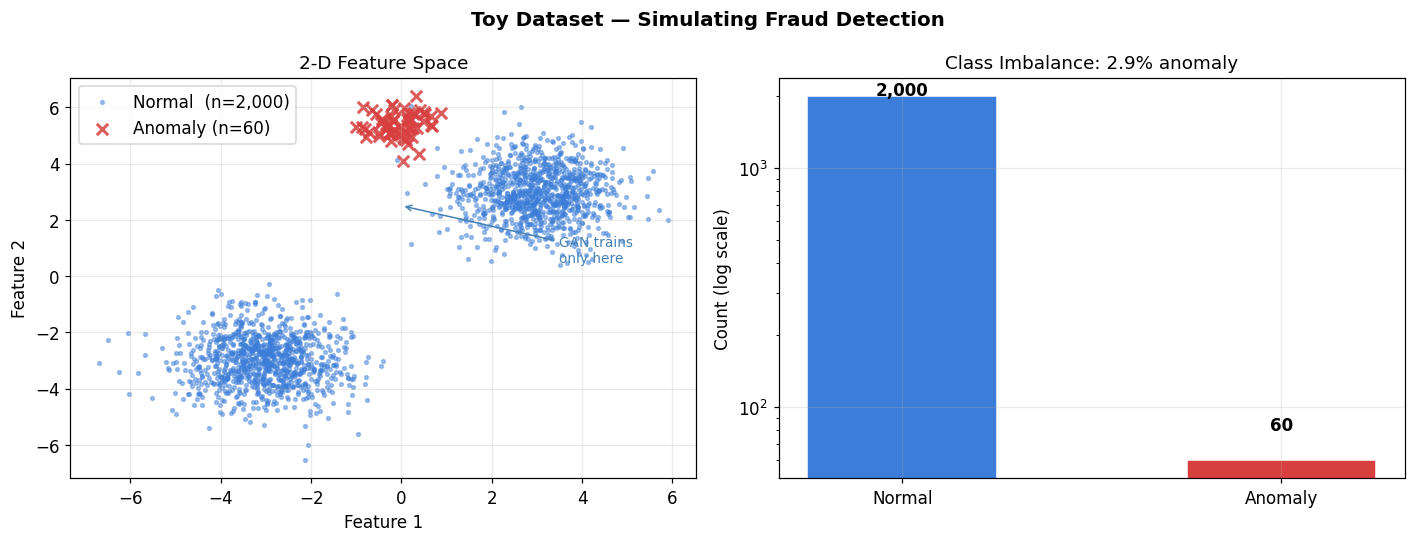

Training set: 2,000 normal samples ONLY (anomalies are held out for evaluation)


In [4]:
# ── Visualise the data
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(NORMAL_DATA[:, 0],  NORMAL_DATA[:, 1],
           s=6, c=CBLUE, alpha=0.45, label=f'Normal  (n={N_NORMAL:,})')
ax.scatter(ANOMALY_DATA[:, 0], ANOMALY_DATA[:, 1],
           s=55, c=CRED, alpha=0.85, marker='x', linewidths=2,
           label=f'Anomaly (n={N_ANOMALY})')
ax.set_title('2-D Feature Space')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend()
ax.annotate('GAN trains\nonly here', xy=(0, 2.5), xytext=(3.5, 0.5),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            fontsize=9, color='steelblue')

ax = axes[1]
bars = ax.bar(['Normal', 'Anomaly'], [N_NORMAL, N_ANOMALY],
              color=[CBLUE, CRED], width=0.5, edgecolor='white')
for bar, cnt in zip(bars, [N_NORMAL, N_ANOMALY]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{cnt:,}', ha='center', fontweight='bold')
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'Class Imbalance: {N_ANOMALY/(N_NORMAL+N_ANOMALY)*100:.1f}% anomaly')

plt.suptitle('Toy Dataset — Simulating Fraud Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training set: {N_NORMAL:,} normal samples ONLY (anomalies are held out for evaluation)")

---
## Part 1 — Vanilla GAN

### The Minimax Game (Goodfellow et al., 2014)

Two networks compete:

| Network | Goal | Input | Output |
|---------|------|-------|--------|
| **Generator G** | Fool the discriminator | Noise $z \sim \mathcal{N}(0,I)$ | Fake sample $\tilde{x}$ |
| **Discriminator D** | Distinguish real from fake | Sample $x$ | $P(\text{real}) \in (0,1)$ |

The joint objective:

$$\min_G \max_D \; \underbrace{\mathbb{E}_{x \sim p_r}[\log D(x)]}_{\text{D wants} \to 1 \text{ on real}} + \underbrace{\mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]}_{\text{D wants} \to 0 \text{ on fake, G wants} \to 1}$$

**At equilibrium:** $D^*(x) = \frac{p_r(x)}{p_r(x) + p_g(x)} = 0.5$ everywhere.

### Practical Generator Loss (Non-Saturating)

The original loss $\log(1 - D(G(z)))$ **saturates** when D is strong (gradients vanish).  
In practice we flip the sign for G:

$$\mathcal{L}_G = -\mathbb{E}_{z}[\log D(G(z))]$$

### The Kullback-Liebler Distance

Reaches the minimum when p(x) == q(x) everywhere:

$$
D_{\mathrm{KL}}(p \,\|\, q)
= \int_x p(x)\, \log \frac{p(x)}{q(x)} \, dx
$$


### Jensen-Shannon Divergence


$$
D_{\mathrm{JS}}(p \,\|\, q)
= \frac{1}{2} D_{\mathrm{KL}}\!\left(p \,\Big\|\, \frac{p + q}{2}\right)
+ \frac{1}{2} D_{\mathrm{KL}}\!\left(q \,\Big\|\, \frac{p + q}{2}\right)
$$


### Known Problems with Vanilla GAN

1. **Training instability** — loss based on Jensen-Shannon divergence, which becomes *constant*  
   when $p_r$ and $p_g$ have disjoint supports (common early in training).
2. **Mode collapse** — G learns to output only one mode to reliably fool D.
3. **No interpretable metric** — D loss gives no signal about generation quality.
4. **Score not usable for anomaly detection** — D outputs a *probability* tied to the  
   current G, not a measure of how "normal" the input is.

For detailed discussion, refer to https://arxiv.org/pdf/1511.05101 

In [5]:
# ── Vanilla GAN Architecture

class VanillaGenerator(nn.Module):
    """
    z (noise, 16-D) → x̃ (fake sample, 2-D).
    Uses plain ReLU — we'll explain why this is problematic shortly.
    No activation on output layer so values can be any real number.
    """
    def __init__(self, z_dim=Z_DIM, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden),   nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, out_dim),             # unbounded output
        )
    def forward(self, z):
        return self.net(z)


class VanillaDiscriminator(nn.Module):
    """
    x (2-D) → P(real) ∈ (0, 1).
    Sigmoid output: 1 = real, 0 = fake.
    Problem: this is NOT comparable across training steps.
    """
    def __init__(self, in_dim=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),  nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid(),               # ← clips gradients, bounds output
        )
    def forward(self, x):
        return self.net(x)


# ── ASCII diagram 
print("  VANILLA GAN ARCHITECTURE")
print("  " + "═"*44)
print("  z ~ N(0,I)   [16-dim noise]")
print("       │")
print("  ┌────▼──────────────────────────────┐")
print("  │  Generator G                      │")
print("  │  Linear(16→64) → ReLU             │")
print("  │  Linear(64→64) → ReLU             │")
print("  │  Linear(64→2)  [no activation]    │")
print("  └────────────────────────────────┬──┘")
print("              fake x̃ [2-dim]       │")
print("       ┌────────────────────────────┘")
print("  ┌────▼──────────────────────────────┐")
print("  │  Discriminator D                  │")
print("  │  Linear(2→64)  → ReLU             │")
print("  │  Linear(64→64) → ReLU             │")
print("  │  Linear(64→1)  → Sigmoid          │")
print("  └───────────────────────────────────┘")
print("       │  P(real) ∈ (0,1)")
print()

G_van = VanillaGenerator()
D_van = VanillaDiscriminator()
n_g = sum(p.numel() for p in G_van.parameters())
n_d = sum(p.numel() for p in D_van.parameters())
print(f"  Generator parameters    : {n_g:,}")
print(f"  Discriminator parameters: {n_d:,}")

  VANILLA GAN ARCHITECTURE
  ════════════════════════════════════════════
  z ~ N(0,I)   [16-dim noise]
       │
  ┌────▼──────────────────────────────┐
  │  Generator G                      │
  │  Linear(16→64) → ReLU             │
  │  Linear(64→64) → ReLU             │
  │  Linear(64→2)  [no activation]    │
  └────────────────────────────────┬──┘
              fake x̃ [2-dim]       │
       ┌────────────────────────────┘
  ┌────▼──────────────────────────────┐
  │  Discriminator D                  │
  │  Linear(2→64)  → ReLU             │
  │  Linear(64→64) → ReLU             │
  │  Linear(64→1)  → Sigmoid          │
  └───────────────────────────────────┘
       │  P(real) ∈ (0,1)

  Generator parameters    : 5,378
  Discriminator parameters: 4,417


In [6]:
# ── Vanilla GAN Training
torch.manual_seed(SEED)

G_van = VanillaGenerator()
D_van = VanillaDiscriminator()
opt_g = optim.Adam(G_van.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = optim.Adam(D_van.parameters(), lr=2e-4, betas=(0.5, 0.999))

real_t = torch.tensor(NORMAL_DATA, dtype=torch.float32)  # ONLY normal data

N_STEPS  = 3000
d_hist, g_hist, real_sc_hist, fake_sc_hist = [], [], [], []
snapshots_van = {}

for step in range(N_STEPS):
    # ─── Discriminator update 
    idx  = torch.randint(0, len(real_t), (BATCH,))
    real = real_t[idx]
    z    = torch.randn(BATCH, Z_DIM)
    fake = G_van(z).detach()

    d_real = D_van(real)          # want → 1
    d_fake = D_van(fake)          # want → 0

    # Binary cross-entropy (log D(real) + log(1 - D(fake)))
    loss_d = -(torch.log(d_real + 1e-8) + torch.log(1 - d_fake + 1e-8)).mean()
    opt_d.zero_grad(); loss_d.backward(); opt_d.step()

    # ─── Generator update 
    z    = torch.randn(BATCH, Z_DIM)
    fake = G_van(z)
    # Non-saturating: -log D(G(z))
    loss_g = -torch.log(D_van(fake) + 1e-8).mean()
    opt_g.zero_grad(); loss_g.backward(); opt_g.step()

    d_hist.append(loss_d.item())
    g_hist.append(loss_g.item())
    with torch.no_grad():
        real_sc_hist.append(D_van(real[:64]).mean().item())
        fake_sc_hist.append(D_van(fake.detach()[:64]).mean().item())

    if step in (0, 300, 1000, 2999):
        with torch.no_grad():
            snapshots_van[step] = G_van(torch.randn(800, Z_DIM)).numpy()

print("Vanilla GAN training done.")

Vanilla GAN training done.


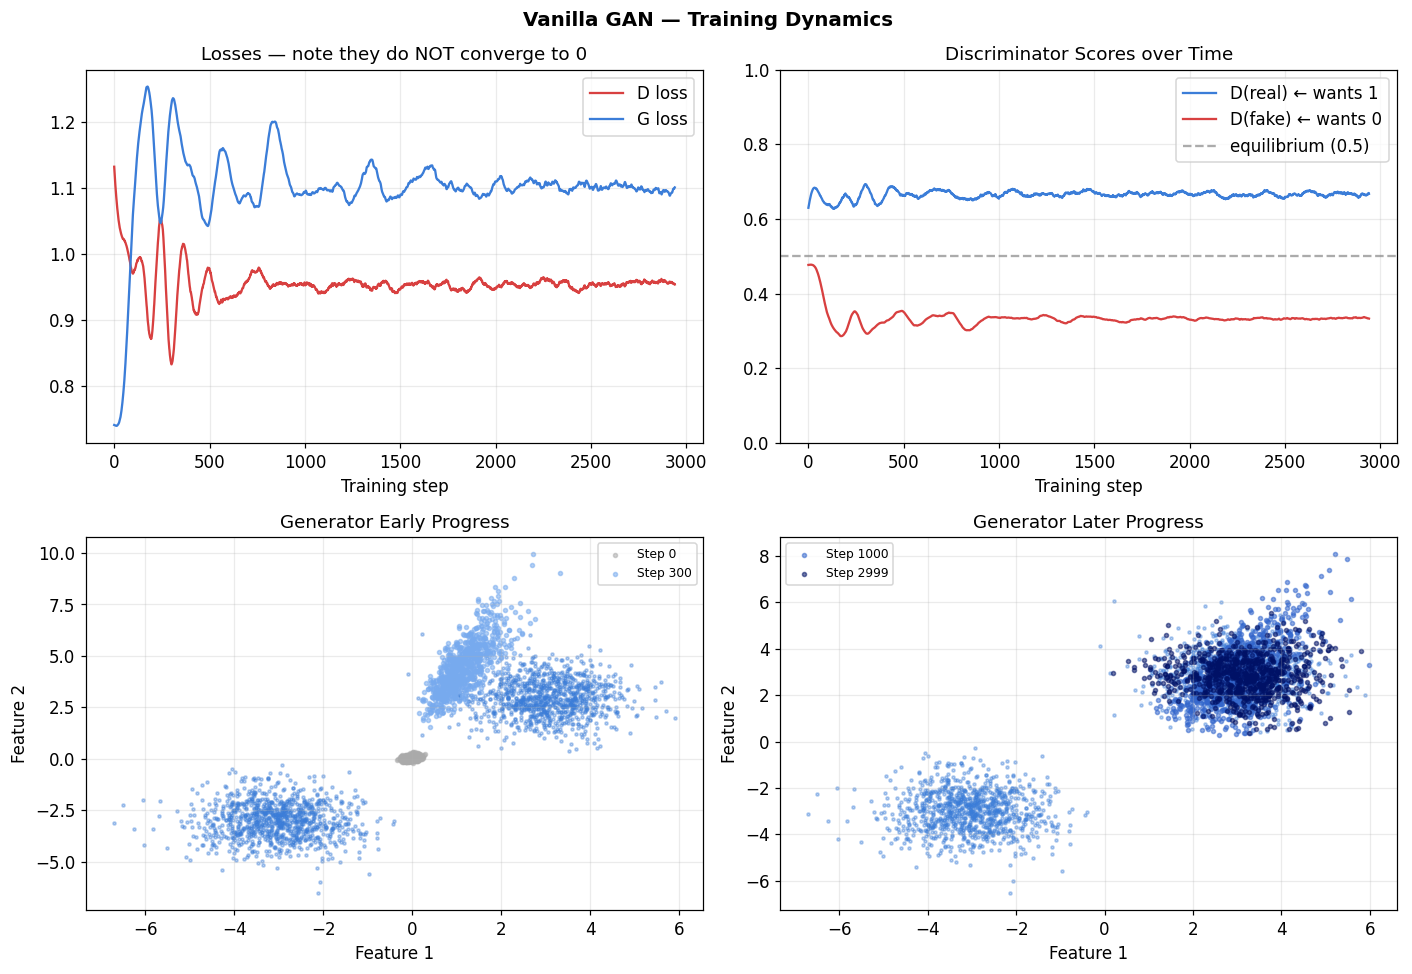

In [7]:
# ── Training dynamics plot
smooth = lambda v, w=60: np.convolve(v, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.plot(smooth(d_hist), color=CRED,   label='D loss', lw=1.5)
ax.plot(smooth(g_hist), color=CBLUE,  label='G loss', lw=1.5)
ax.set_title('Losses — note they do NOT converge to 0')
ax.set_xlabel('Training step'); ax.legend()

ax = axes[0, 1]
ax.plot(smooth(real_sc_hist), color=CBLUE, label='D(real) ← wants 1', lw=1.5)
ax.plot(smooth(fake_sc_hist), color=CRED,  label='D(fake) ← wants 0', lw=1.5)
ax.axhline(0.5, ls='--', c=CGRAY, alpha=0.7, label='equilibrium (0.5)')
ax.set_ylim(0, 1); ax.set_title('Discriminator Scores over Time')
ax.set_xlabel('Training step'); ax.legend()

for step_key, ax_idx, color in [
        (0, (1,0), '#aaaaaa'), (300, (1,0), '#77aaee'),
        (1000, (1,1), '#3366cc'), (2999, (1,1), '#001166')]:
    ax = axes[ax_idx]
    ax.scatter(NORMAL_DATA[:,0], NORMAL_DATA[:,1], s=4, c=CBLUE, alpha=0.2, zorder=0)
    samp = snapshots_van[step_key]
    ax.scatter(samp[:,0], samp[:,1], s=7, c=color, alpha=0.55,
               label=f'Step {step_key}')
axes[1,0].set_title('Generator Early Progress'); axes[1,0].legend(fontsize=8)
axes[1,1].set_title('Generator Later Progress'); axes[1,1].legend(fontsize=8)
for ax in axes[1,:]:
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('Vanilla GAN — Training Dynamics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [8]:
# ── Vanilla GAN: failure analysis
with torch.no_grad():
    gen_samples_van = G_van(torch.randn(2000, Z_DIM)).numpy()

# Mode collapse indicator: covariance determinant
data_cov_det = np.linalg.det(np.cov(NORMAL_DATA.T))
gen_cov_det  = np.linalg.det(np.cov(gen_samples_van.T))

print("═"*52)
print("  Vanilla GAN — Coverage Check")
print("═"*52)
print(f"  Real data   covariance det : {data_cov_det:.4f}")
print(f"  Generator   covariance det : {gen_cov_det:.4f}")
ratio = gen_cov_det / (data_cov_det + 1e-9)
print(f"  Ratio (1.0 = perfect, → 0 = mode collapse): {ratio:.3f}")
print()

════════════════════════════════════════════════════
  Vanilla GAN — Coverage Check
════════════════════════════════════════════════════
  Real data   covariance det : 15.5158
  Generator   covariance det : 0.5747
  Ratio (1.0 = perfect, → 0 = mode collapse): 0.037



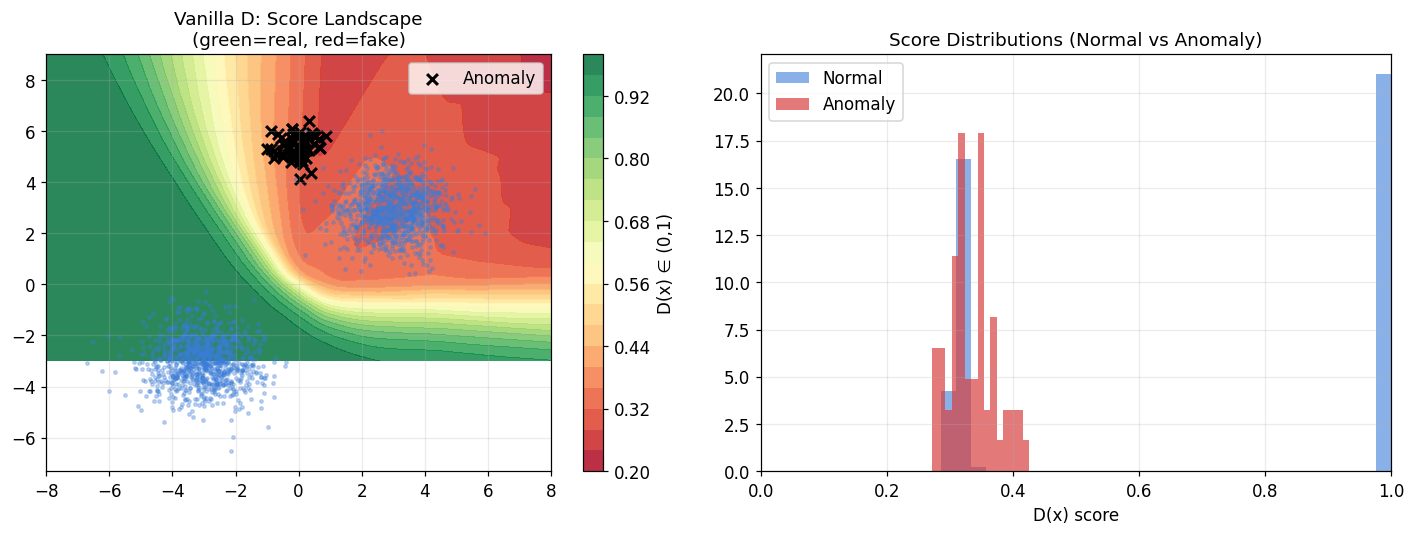

  Vanilla GAN anomaly detection PR-AUC : 0.205
  Random baseline                       : 0.029

  Problems we observed:
  ✗ Loss curves oscillate — no clear convergence signal
  ✗ Score landscape may not cleanly separate anomalies
  ✗ D score is probability relative to current G — not 'normalcy'
  ✗ Potential mode collapse (covariance det << real data)


In [9]:
# Score landscape + histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

xg = np.linspace(-8, 8, 90)
yg = np.linspace(-3, 9, 90)
XX, YY = np.meshgrid(xg, yg)
grid_t = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z_van = D_van(grid_t).numpy().reshape(90, 90)
    sc_normal  = D_van(torch.tensor(NORMAL_DATA)).squeeze().numpy()
    sc_anomaly = D_van(torch.tensor(ANOMALY_DATA)).squeeze().numpy()

ax = axes[0]
cf = ax.contourf(XX, YY, Z_van, levels=20, cmap='RdYlGn', alpha=0.85)
plt.colorbar(cf, ax=ax, label='D(x) ∈ (0,1)')
ax.scatter(NORMAL_DATA[:,0],  NORMAL_DATA[:,1],  s=5,  c=CBLUE, alpha=0.3)
ax.scatter(ANOMALY_DATA[:,0], ANOMALY_DATA[:,1], s=50, c='black', marker='x',
           linewidths=2, label='Anomaly')
ax.set_title('Vanilla D: Score Landscape\n(green=real, red=fake)')
ax.legend()

ax = axes[1]
ax.hist(sc_normal,  bins=30, color=CBLUE, alpha=0.6, label='Normal',  density=True)
ax.hist(sc_anomaly, bins=15, color=CRED,  alpha=0.7, label='Anomaly', density=True)
ax.set_xlabel('D(x) score'); ax.set_title('Score Distributions (Normal vs Anomaly)')
ax.legend()
ax.set_xlim(0, 1)

plt.tight_layout(); plt.show()

# Anomaly detection quality
all_sc  = np.concatenate([-sc_normal, -sc_anomaly])   # anomaly = -D
all_lbl = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])
pr_auc_van = average_precision_score(all_lbl, all_sc)
print(f"  Vanilla GAN anomaly detection PR-AUC : {pr_auc_van:.3f}")
print(f"  Random baseline                       : {N_ANOMALY/(N_NORMAL+N_ANOMALY):.3f}")
print()
print("  Problems we observed:")
print("  ✗ Loss curves oscillate — no clear convergence signal")
print("  ✗ Score landscape may not cleanly separate anomalies")
print("  ✗ D score is probability relative to current G — not 'normalcy'")
print("  ✗ Potential mode collapse (covariance det << real data)")

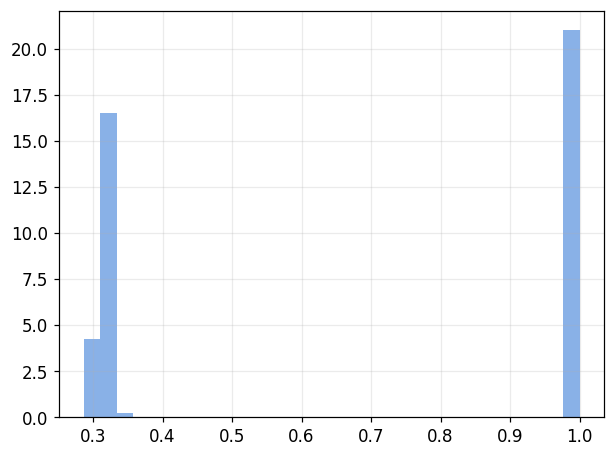

In [10]:
plot1 = plt.hist(sc_normal,  bins=30, color=CBLUE, alpha=0.6, label='Normal',  density=True)

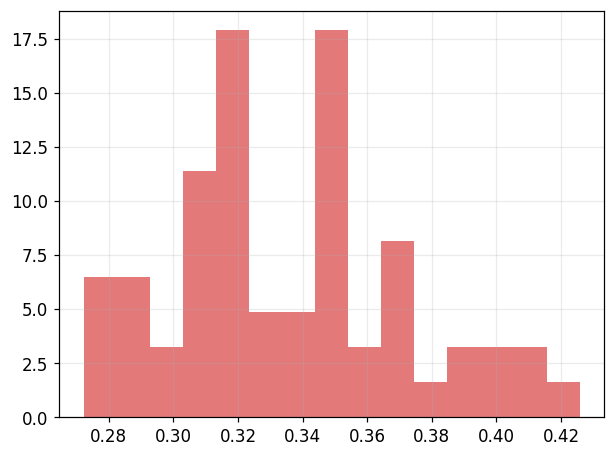

In [11]:
plot2 = plt.hist(sc_anomaly, bins=15, color=CRED,  alpha=0.7, label='Anomaly', density=True)

---
## Part 2 — Wasserstein GAN (WGAN)

### The Root Cause: Jensen-Shannon Divergence

Vanilla GAN minimises the **Jensen-Shannon (JS) divergence**:

$$\text{JS}(p_r \| p_g) = \frac{1}{2} \text{KL}\!\left(p_r \Big\| \frac{p_r+p_g}{2}\right) + \frac{1}{2}\text{KL}\!\left(p_g \Big\| \frac{p_r+p_g}{2}\right)$$

When $p_r$ and $p_g$ have **disjoint support** (common early in training):
$$\text{JS}(p_r \| p_g) = \log 2 \quad \text{(constant!)}$$

→ Zero gradient for G → training stalls.

### The Fix: Earth Mover's (Wasserstein-1) Distance

$$W(p_r, p_g) = \inf_{\gamma \in \Pi(p_r, p_g)} \mathbb{E}_{(x,y)\sim\gamma}\left[\|x - y\|\right]$$

Intuitively: minimum "cost" to transport mass from $p_r$ to $p_g$.  
This is **always differentiable**, even when supports are disjoint.

### Wasserstein GAN Objective (Arjovsky et al., 2017)

By the **Kantorovich-Rubinstein duality**, for 1-Lipschitz functions $f$:

$$W(p_r, p_g) = \sup_{\|f\|_L \leq 1} \mathbb{E}_{x \sim p_r}[f(x)] - \mathbb{E}_{z \sim p_z}[f(G(z))]$$

The critic $C$ approximates this optimal $f$. Training becomes:

$$\min_G \max_{C \in \mathcal{F}_L} \; \underbrace{\mathbb{E}_{x \sim p_r}[C(x)]}_{\text{mean real score}} - \underbrace{\mathbb{E}_{z}[C(G(z))]}_{\text{mean fake score}}$$

Key differences from vanilla GAN:
- **No Sigmoid** on critic output — scores are unbounded real numbers
- **Critic loss = Wasserstein estimate** — meaningful, correlates with quality
- **1-Lipschitz constraint** must be enforced (weight clipping → GP)

### Why LeakyReLU instead of ReLU?

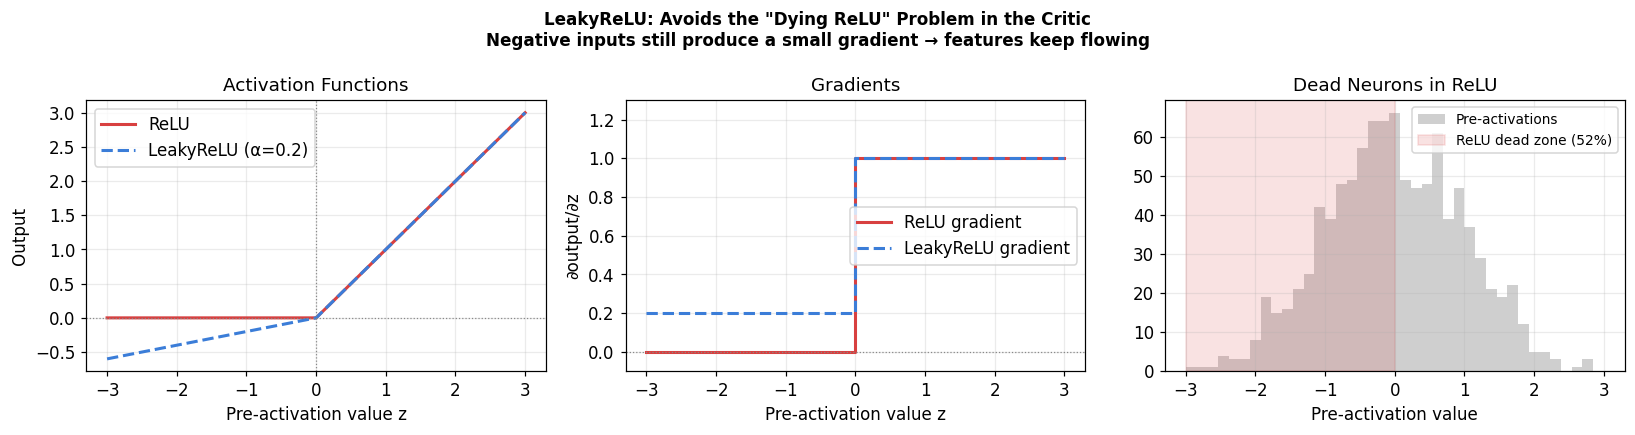

Why LeakyReLU matters for the critic:
  • ReLU kills gradients for z < 0 (neuron permanently silent)
  • In the critic, we need gradients to flow through ALL inputs
  • Real data features can be negative → must not be silenced
  • LeakyReLU α=0.2 passes 20% of negative signal through


In [12]:
# ── Why LeakyReLU instead of ReLU?

x_vals = np.linspace(-3, 3, 400)

relu       = np.maximum(0, x_vals)
leaky      = np.where(x_vals >= 0, x_vals, 0.2 * x_vals)
relu_grad  = (x_vals >= 0).astype(float)
leaky_grad = np.where(x_vals >= 0, 1.0, 0.2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Activation comparison
ax = axes[0]
ax.plot(x_vals, relu,  color=CRED,  lw=2, label='ReLU')
ax.plot(x_vals, leaky, color=CBLUE, lw=2, label='LeakyReLU (α=0.2)', ls='--')
ax.axvline(0, c=CGRAY, lw=0.8, ls=':')
ax.axhline(0, c=CGRAY, lw=0.8, ls=':')
ax.set_title('Activation Functions')
ax.set_xlabel('Pre-activation value z')
ax.set_ylabel('Output')
ax.legend()

# Gradient comparison
ax = axes[1]
ax.step(x_vals, relu_grad,  color=CRED,  lw=2, label='ReLU gradient', where='mid')
ax.step(x_vals, leaky_grad, color=CBLUE, lw=2, label='LeakyReLU gradient', where='mid', ls='--')
ax.axhline(0, c=CGRAY, lw=0.8, ls=':')
ax.set_title('Gradients')
ax.set_xlabel('Pre-activation value z')
ax.set_ylabel('∂output/∂z')
ax.set_ylim(-0.1, 1.3)
ax.legend()

# Dead neuron illustration
ax = axes[2]
np.random.seed(SEED)
pre_activations = np.random.randn(1000)
dead_relu   = (pre_activations < 0).sum()
dead_leaky  = 0   # leaky never fully "dies"

bins = np.linspace(-3, 3, 40)
ax.hist(pre_activations, bins=bins, color=CGRAY, alpha=0.4, label='Pre-activations')
ax.axvspan(-3, 0, alpha=0.15, color=CRED, label=f'ReLU dead zone ({dead_relu/10:.0f}%)')
ax.set_title('Dead Neurons in ReLU')
ax.set_xlabel('Pre-activation value')
ax.legend(fontsize=9)

plt.suptitle(
    'LeakyReLU: Avoids the "Dying ReLU" Problem in the Critic\n'
    'Negative inputs still produce a small gradient → features keep flowing',
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print("Why LeakyReLU matters for the critic:")
print("  • ReLU kills gradients for z < 0 (neuron permanently silent)")
print("  • In the critic, we need gradients to flow through ALL inputs")
print("  • Real data features can be negative → must not be silenced")
print("  • LeakyReLU α=0.2 passes 20% of negative signal through")

### WGAN Architecture (improved)

In [13]:
# ── WGAN Architecture (improved)

class WGANGenerator(nn.Module):
    """
    Same generator, now with LeakyReLU.
    Tanh output keeps values in [-1, 1] — good match for RobustScaler output.
    """
    def __init__(self, z_dim=Z_DIM, hidden=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden),   nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),  nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),  nn.LeakyReLU(0.2),
            nn.Linear(hidden, out_dim), nn.Tanh(),   # bounded output
        )
    def forward(self, z):
        return self.net(z)


class WGANCritic(nn.Module):
    """
    Wasserstein Critic:
    - NO Sigmoid — output is unbounded real number (Wasserstein score)
    - Higher score = more normal-like
    - LeakyReLU throughout
    
    The 1-Lipschitz constraint is enforced by weight clipping (original WGAN)
    or gradient penalty (WGAN-GP, preferred).
    """
    def __init__(self, in_dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),  nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),  nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),  nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),       # ← NO activation!
        )
    def forward(self, x):
        return self.net(x)


print("  WGAN IMPROVEMENTS vs VANILLA GAN")
print("  " + "═"*44)
print()
print("  Critic changes:")
print("    ReLU      → LeakyReLU(0.2)   [avoids dead neurons]")
print("    Sigmoid   → removed          [unbounded Wasserstein scores]")
print()
print("  Interpretation change:")
print("    D(x) ∈ (0,1)  [probability]")
print("    C(x) ∈ ℝ      [normalcy score, comparable across steps]")
print()
print("  Loss change:")
print("    D: -E[logD(real)] - E[log(1-D(fake))]   [BCE]")
print("    C: E[C(fake)] - E[C(real)]               [Wasserstein]")
print()

G_wgan = WGANGenerator()
C_wgan = WGANCritic()
print(f"  Generator parameters: {sum(p.numel() for p in G_wgan.parameters()):,}")
print(f"  Critic   parameters : {sum(p.numel() for p in C_wgan.parameters()):,}")

  WGAN IMPROVEMENTS vs VANILLA GAN
  ════════════════════════════════════════════

  Critic changes:
    ReLU      → LeakyReLU(0.2)   [avoids dead neurons]
    Sigmoid   → removed          [unbounded Wasserstein scores]

  Interpretation change:
    D(x) ∈ (0,1)  [probability]
    C(x) ∈ ℝ      [normalcy score, comparable across steps]

  Loss change:
    D: -E[logD(real)] - E[log(1-D(fake))]   [BCE]
    C: E[C(fake)] - E[C(real)]               [Wasserstein]

  Generator parameters: 35,458
  Critic   parameters : 33,537


### WGAN Training (weight clipping version for comparison)

In [14]:
# ── WGAN Training (weight clipping version for comparison) ───────────────────
# NOTE: weight clipping is the *original* WGAN approach.
#       It works but causes problems (see Part 3 for gradient penalty fix).

torch.manual_seed(SEED)
G_wgan = WGANGenerator()
C_wgan_clip = WGANCritic()

opt_g = optim.RMSprop(G_wgan.parameters(), lr=5e-5)
opt_c = optim.RMSprop(C_wgan_clip.parameters(), lr=5e-5)

real_t = torch.tensor(NORMAL_DATA, dtype=torch.float32)

N_CRITIC = 5   # critic updates per generator update
C_CLIP   = 0.01  # weight clipping parameter

w_dist_hist, real_score_hist, fake_score_hist = [], [], []
snap_wgan = {}

N_STEPS_WGAN = 3000

for step in range(N_STEPS_WGAN):
    for _ in range(N_CRITIC):
        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_wgan(z).detach()

        # Wasserstein critic loss: minimise E[C(fake)] - E[C(real)]
        loss_c = C_wgan_clip(fake).mean() - C_wgan_clip(real).mean()
        opt_c.zero_grad(); loss_c.backward(); opt_c.step()

        # Weight clipping — enforces Lipschitz (crude but simple)
        for p in C_wgan_clip.parameters():
            p.data.clamp_(-C_CLIP, C_CLIP)

    # Generator: maximise C(fake) i.e. minimise -C(fake)
    z    = torch.randn(BATCH, Z_DIM)
    fake = G_wgan(z)
    loss_g = -C_wgan_clip(fake).mean()
    opt_g.zero_grad(); loss_g.backward(); opt_g.step()

    with torch.no_grad():
        rs = C_wgan_clip(real[:64]).mean().item()
        fs = C_wgan_clip(G_wgan(torch.randn(64, Z_DIM))).mean().item()
        real_score_hist.append(rs)
        fake_score_hist.append(fs)
        w_dist_hist.append(rs - fs)   # Wasserstein estimate = E[C(real)] - E[C(fake)]

    if step in (0, 500, 1500, 2999):
        with torch.no_grad():
            snap_wgan[step] = G_wgan(torch.randn(800, Z_DIM)).numpy()

print("WGAN (weight clipping) training done.")

WGAN (weight clipping) training done.


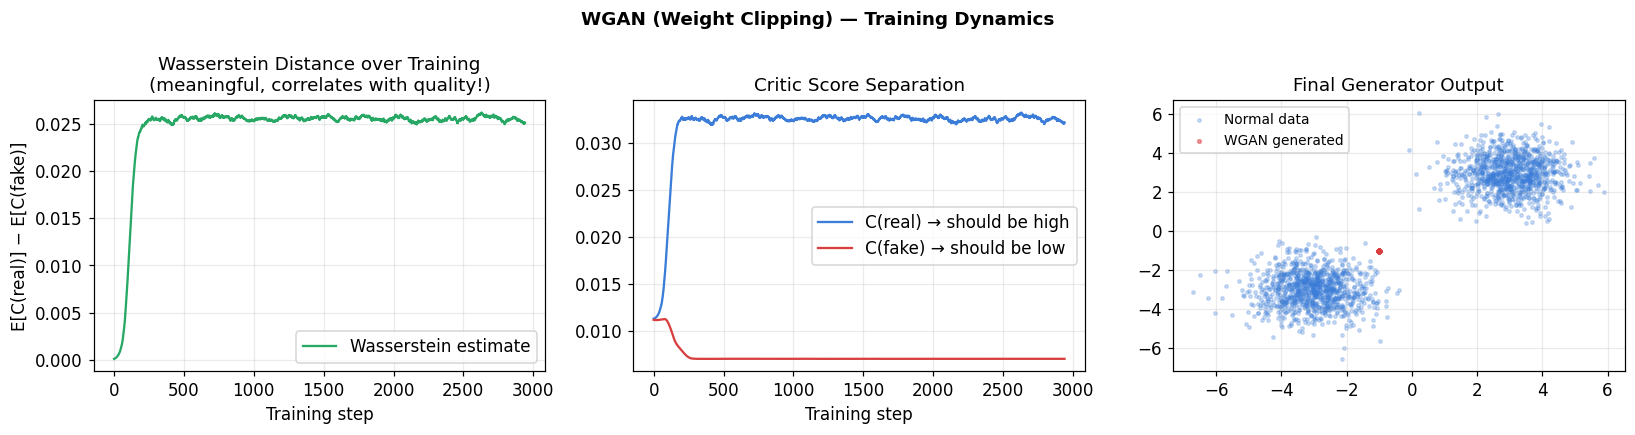


Weight clipping problem: clipping to [-0.01, 0.01] forces weights
to be very small → critic capacity is severely limited.
Solution: Gradient Penalty (Part 3)


In [15]:
# ── Plot:
smooth = lambda v, w=60: np.convolve(v, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(smooth(w_dist_hist), color=CGREEN, lw=1.5, label='Wasserstein estimate')
ax.set_title('Wasserstein Distance over Training\n(meaningful, correlates with quality!)')
ax.set_xlabel('Training step'); ax.set_ylabel('E[C(real)] − E[C(fake)]'); ax.legend()

ax = axes[1]
ax.plot(smooth(real_score_hist), color=CBLUE, lw=1.5, label='C(real) → should be high')
ax.plot(smooth(fake_score_hist), color=CRED,  lw=1.5, label='C(fake) → should be low')
ax.set_title('Critic Score Separation')
ax.set_xlabel('Training step'); ax.legend()

ax = axes[2]
with torch.no_grad():
    samp = G_wgan(torch.randn(1000, Z_DIM)).numpy()
ax.scatter(NORMAL_DATA[:,0], NORMAL_DATA[:,1], s=5, c=CBLUE, alpha=0.25, label='Normal data')
ax.scatter(samp[:,0], samp[:,1], s=6, c=CRED, alpha=0.5, label='WGAN generated')
ax.set_title('Final Generator Output')
ax.legend(fontsize=9)

plt.suptitle('WGAN (Weight Clipping) — Training Dynamics', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nWeight clipping problem: clipping to [-0.01, 0.01] forces weights")
print("to be very small → critic capacity is severely limited.")
print("Solution: Gradient Penalty (Part 3)")

---
## Part 3 - WGAN-GP: Enforcing Lipschitz via Gradient Penalty

### The Problem with Weight Clipping

Weight clipping forces all weights into $[-c, c]$, which:
- Drastically limits critic capacity (can only represent simple functions)
- Encourages extreme values ($+c$ or $-c$), leading to vanishing gradients

### Gradient Penalty (Gulrajani et al., 2017)

The **1-Lipschitz** condition is equivalent to:
$$\|\nabla_x C(x)\|_2 \leq 1 \quad \forall x$$

Instead of constraining weights, we **penalise violations directly**:

$$\mathcal{L}^{GP} = \lambda \cdot \mathbb{E}_{\hat{x} \sim \mathbb{P}_{\hat{x}}} \!\left[\left(\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1\right)^2\right]$$

where $\hat{x} = \alpha x_r + (1-\alpha) x_f$, $\alpha \sim U(0,1)$ — **interpolated samples**.

We penalise on the line connecting real and fake samples, not on the data directly.

### Full WGAN-GP Critic Loss

$$\mathcal{L}_C = \underbrace{\mathbb{E}[C(\tilde{x})]}_{\text{wants small}} - \underbrace{\mathbb{E}[C(x)]}_{\text{wants large}} + \underbrace{\lambda \mathbb{E}\!\left[(\|\nabla C(\hat{x})\|_2 - 1)^2\right]}_{\text{Lipschitz penalty}}$$

### R1 Regularisation (Alternative)

A simpler alternative that penalises gradients on **real** samples only:

$$\mathcal{L}^{R1} = \frac{\gamma}{2} \mathbb{E}_{x \sim p_r}\!\left[\|\nabla_x C(x)\|^2\right]$$

Advantages of R1: single forward pass on real data only, no interpolation needed.  
In practice both work well; GP is more theoretically principled.

### Generator Loss

$$\mathcal{L}_G = -\mathbb{E}_z[C(G(z))] + \lambda_\text{recon} \cdot \mathbb{E}\!\left[\|G(z) - x\|_2^2\right]$$

The reconstruction term encourages the generator to stay close to the normal manifold.

In [16]:
# ── Gradient Penalty: implementation + visual explanation

def gradient_penalty(critic, real, fake, lambda_gp=10.0):
    """
    WGAN-GP gradient penalty.
    
    Computes: λ · E[(‖∇_x̂ C(x̂)‖₂ - 1)²]
    where x̂ = α·real + (1-α)·fake,  α ~ U(0,1)
    
    Args:
        critic   : the critic network
        real     : real samples  [B, features]
        fake     : generated samples [B, features] — must be DETACHED from G
        lambda_gp: penalty coefficient
    Returns:
        scalar GP loss term (already multiplied by lambda_gp)
    """
    batch  = min(real.size(0), fake.size(0))
    alpha  = torch.rand(batch, 1)   # random interpolation coefficient

    # Interpolated samples — on the line between real and fake
    interp = (alpha * real[:batch] + (1 - alpha) * fake[:batch]).requires_grad_(True)

    d_interp = critic(interp)  # critic score at interpolated point

    # Compute gradient of critic score w.r.t. interpolated input
    grads = torch.autograd.grad(
        outputs     = d_interp,
        inputs      = interp,
        grad_outputs= torch.ones_like(d_interp),
        create_graph= True,   # allow second-order gradients
        retain_graph= True,
    )[0]   # shape: [batch, n_features]

    grad_norms = grads.view(batch, -1).norm(2, dim=1)  # ‖∇C(x̂)‖₂
    return lambda_gp * ((grad_norms - 1.0) ** 2).mean()


def r1_penalty(critic, real, gamma=10.0):
    """
    R1 regularisation (Mescheder et al., 2018).
    Simpler: penalise gradients on REAL samples only.
    """
    real = real.detach().requires_grad_(True)
    score = critic(real)
    grads = torch.autograd.grad(
        outputs=score.sum(), inputs=real, create_graph=True
    )[0]
    return gamma / 2 * grads.pow(2).sum(dim=1).mean()


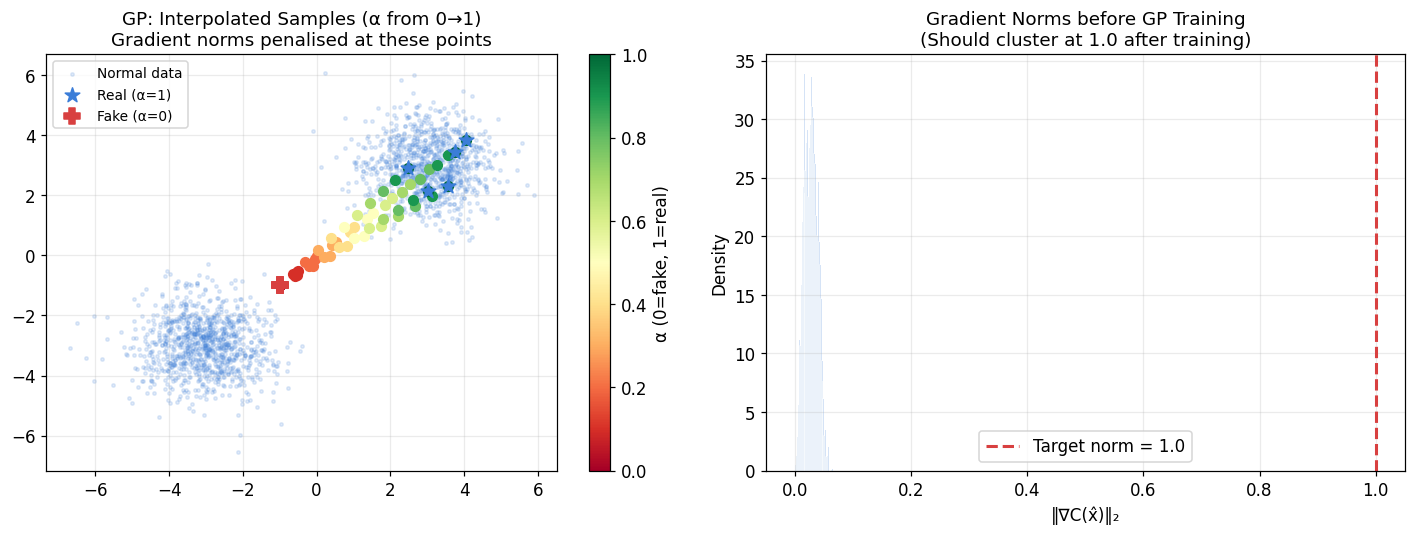

GP penalises points where ‖∇C(x̂)‖₂ ≠ 1.0
After training, gradient norms should concentrate near 1.0


In [17]:
# ── Visualise: what does the interpolation look like?
torch.manual_seed(SEED + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Show interpolated samples between real and fake
real_ex  = torch.tensor(NORMAL_DATA[:5], dtype=torch.float32)
z_ex     = torch.randn(5, Z_DIM)
fake_ex  = G_wgan(z_ex).detach()

ax = axes[0]
ax.scatter(NORMAL_DATA[:,0], NORMAL_DATA[:,1], s=5, c=CBLUE, alpha=0.15, label='Normal data')

colors_interp = plt.cm.RdYlGn(np.linspace(0, 1, 11))
for i, alpha_val in enumerate(np.linspace(0, 1, 11)):
    interp_pts = alpha_val * real_ex.numpy() + (1-alpha_val) * fake_ex.numpy()
    ax.scatter(interp_pts[:,0], interp_pts[:,1], s=40,
               color=colors_interp[i], zorder=3)

ax.scatter(real_ex[:,0].numpy(), real_ex[:,1].numpy(),
           s=100, c=CBLUE, marker='*', zorder=4, label='Real (α=1)')
ax.scatter(fake_ex[:,0].numpy(), fake_ex[:,1].numpy(),
           s=100, c=CRED, marker='P', zorder=4, label='Fake (α=0)')
ax.set_title('GP: Interpolated Samples (α from 0→1)\nGradient norms penalised at these points')
ax.legend(fontsize=9)

sm = ScalarMappable(cmap='RdYlGn', norm=Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='α (0=fake, 1=real)')

# Show gradient norms during a mini-training run
temp_critic = WGANCritic()
temp_real   = torch.tensor(NORMAL_DATA[:256], dtype=torch.float32)

grad_norm_samples = []
for _ in range(200):
    z    = torch.randn(64, Z_DIM)
    fake = G_wgan(z).detach()
    real = temp_real[torch.randint(0, 256, (64,))]
    batch = 64
    alpha = torch.rand(batch, 1)
    interp = (alpha * real + (1-alpha)*fake).requires_grad_(True)
    d_int  = temp_critic(interp)
    grads  = torch.autograd.grad(d_int, interp, torch.ones_like(d_int), create_graph=False)[0]
    grad_norm_samples.extend(grads.view(batch,-1).norm(2, dim=1).detach().numpy().tolist())

ax = axes[1]
ax.hist(grad_norm_samples, bins=40, color=CBLUE, alpha=0.7, edgecolor='white', density=True)
ax.axvline(1.0, color=CRED, lw=2, ls='--', label='Target norm = 1.0')
ax.set_xlabel('‖∇C(x̂)‖₂'); ax.set_ylabel('Density')
ax.set_title('Gradient Norms before GP Training\n(Should cluster at 1.0 after training)')
ax.legend()

plt.tight_layout(); plt.show()
print("GP penalises points where ‖∇C(x̂)‖₂ ≠ 1.0")
print("After training, gradient norms should concentrate near 1.0")

## WGAN-GP: Full Training with Diagnostics

In [18]:
# ── WGAN-GP: Full Training with Diagnostics
torch.manual_seed(SEED)

G_gp = WGANGenerator(z_dim=Z_DIM, hidden=128)
C_gp = WGANCritic(in_dim=2, hidden=128)

opt_g = optim.Adam(G_gp.parameters(), lr=1e-4, betas=(0.5, 0.999))
opt_c = optim.Adam(C_gp.parameters(), lr=1e-4, betas=(0.5, 0.999))

real_t = torch.tensor(NORMAL_DATA, dtype=torch.float32)

N_CRITIC_GP = 4
LAMBDA_GP   = 10.0
N_STEPS_GP  = 4000

wdist_gp, gp_hist, gnorm_d, gnorm_g = [], [], [], []
snap_gp, grad_norm_at_end = {}, []

for step in range(N_STEPS_GP):
    for _ in range(N_CRITIC_GP):
        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_gp(z).detach()

        gp      = gradient_penalty(C_gp, real, fake, LAMBDA_GP)
        r_score = C_gp(real)
        f_score = C_gp(fake)
        loss_c  = f_score.mean() - r_score.mean() + gp

        opt_c.zero_grad(); loss_c.backward()
        torch.nn.utils.clip_grad_norm_(C_gp.parameters(), 1.0)
        opt_c.step()

    z    = torch.randn(BATCH, Z_DIM)
    fake = G_gp(z)
    recon_loss = F.mse_loss(fake, real_t[torch.randint(0, len(real_t), (BATCH,))])
    loss_g = -C_gp(fake).mean() + 0.1 * recon_loss
    opt_g.zero_grad(); loss_g.backward()
    torch.nn.utils.clip_grad_norm_(G_gp.parameters(), 1.0)
    opt_g.step()

    with torch.no_grad():
        rs = C_gp(real[:64]).mean().item()
        fs = C_gp(G_gp(torch.randn(64, Z_DIM))).mean().item()
        wdist_gp.append(rs - fs)
        gp_hist.append(gp.item())

    if step == N_STEPS_GP - 1:
        # Collect gradient norms at end of training
        for _ in range(100):
            z    = torch.randn(64, Z_DIM)
            f    = G_gp(z).detach()
            r    = real_t[torch.randint(0,len(real_t),(64,))]
            alpha = torch.rand(64,1)
            interp = (alpha*r + (1-alpha)*f).requires_grad_(True)
            di = C_gp(interp)
            gr = torch.autograd.grad(di, interp, torch.ones_like(di), create_graph=False)[0]
            grad_norm_at_end.extend(gr.view(64,-1).norm(2,dim=1).detach().numpy().tolist())

    if step in (0, 500, 2000, 3999):
        with torch.no_grad():
            snap_gp[step] = G_gp(torch.randn(800, Z_DIM)).numpy()

print("WGAN-GP training complete.")

WGAN-GP training complete.


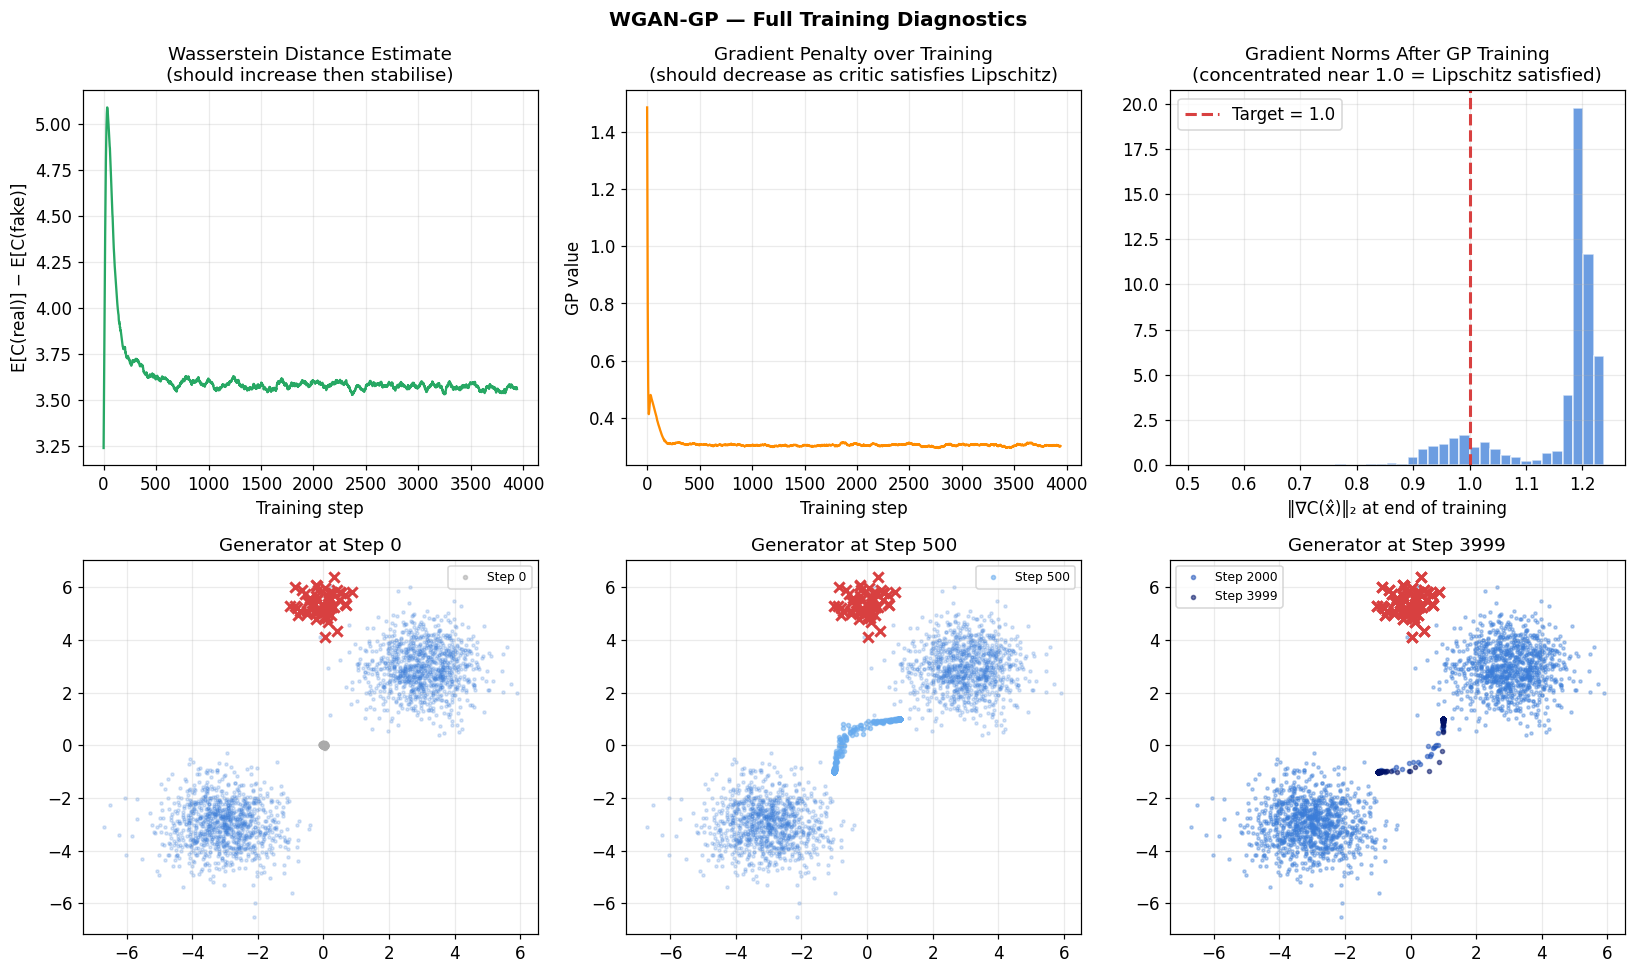

In [19]:
# ── Training Diagnostic plots
smooth = lambda v, w=60: np.convolve(v, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

ax = axes[0, 0]
ax.plot(smooth(wdist_gp), color=CGREEN, lw=1.5)
ax.set_title('Wasserstein Distance Estimate\n(should increase then stabilise)')
ax.set_xlabel('Training step'); ax.set_ylabel('E[C(real)] − E[C(fake)]')

ax = axes[0, 1]
ax.plot(smooth(gp_hist), color='darkorange', lw=1.5)
ax.set_title('Gradient Penalty over Training\n(should decrease as critic satisfies Lipschitz)')
ax.set_xlabel('Training step'); ax.set_ylabel('GP value')

ax = axes[0, 2]
ax.hist(grad_norm_at_end, bins=40, color=CBLUE, alpha=0.75, edgecolor='white', density=True)
ax.axvline(1.0, color=CRED, lw=2, ls='--', label='Target = 1.0')
ax.set_xlabel('‖∇C(x̂)‖₂ at end of training')
ax.set_title('Gradient Norms After GP Training\n(concentrated near 1.0 = Lipschitz satisfied)')
ax.legend()

for step_key, ax_idx, color in [
        (0, (1,0), '#aaaaaa'), (500, (1,0), '#77aaee'),
        (2000, (1,1), '#3366cc'), (3999, (1,2), '#001166')]:
    ax = axes[ax_idx[0], ax_idx[1]] if isinstance(ax_idx, tuple) else axes[1, ax_idx]

for col, (step_key, color) in enumerate([(0,'#aaaaaa'),(500,'#66aaee'),
                                           (2000,'#2255bb'),(3999,'#001166')]):
    ax = axes[1, col] if col < 3 else axes[1, 2]
    ax.scatter(NORMAL_DATA[:,0], NORMAL_DATA[:,1], s=4, c=CBLUE, alpha=0.2)
    ax.scatter(snap_gp[step_key][:,0], snap_gp[step_key][:,1], s=7, c=color,
               alpha=0.55, label=f'Step {step_key}')
    ax.scatter(ANOMALY_DATA[:,0], ANOMALY_DATA[:,1], s=45, c=CRED, marker='x',
               linewidths=2, zorder=3)
    ax.set_title(f'Generator at Step {step_key}')
    ax.legend(fontsize=8)

plt.suptitle('WGAN-GP — Full Training Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 4 - Architecture Design Choices

### Spectral Normalisation

Spectral normalisation (Miyato et al., 2018) controls the Lipschitz constant of each  
linear layer by dividing weights by the largest singular value $\sigma(W)$:

$$\bar{W} = \frac{W}{\sigma(W)}, \quad \text{so} \quad \|\bar{W}\|_\sigma = 1$$

Effect: the full critic satisfies $\|C\|_L \leq \prod_\ell \|\bar{W}_\ell\|_\sigma = 1$ by construction.  
No penalty term needed — Lipschitz is **hard-enforced** by design.

In PyTorch: `torch.nn.utils.spectral_norm(nn.Linear(in, out))`

### Layer Normalisation

For the generator, **LayerNorm** is preferred over BatchNorm because:
- BatchNorm statistics depend on batch size (unstable with small batches)
- LayerNorm normalises across the feature dimension — independent of batch
- Smoother gradient flow through generator layers

$$\text{LayerNorm}(x) = \frac{x - \mu}{\sigma + \epsilon} \cdot \gamma + \beta$$

### Architectural Summary

| Component | Choice | Reason |
|-----------|--------|--------|
| Critic activation | `LeakyReLU(0.2)` | No dead neurons |
| Critic Lipschitz | `spectral_norm` | Hard constraint, no penalty cost |
| Generator activation | `LeakyReLU(0.2)` | Stable gradients |
| Generator normalisation | `LayerNorm` | Batch-size independent |
| Generator output | `Tanh` | Bounded, matches normalised data |
| Critic output | *none* | Unbounded Wasserstein scores |
| Optimiser | `Adam(β₁=0.5, β₂=0.999)` | Standard WGAN-GP setting |

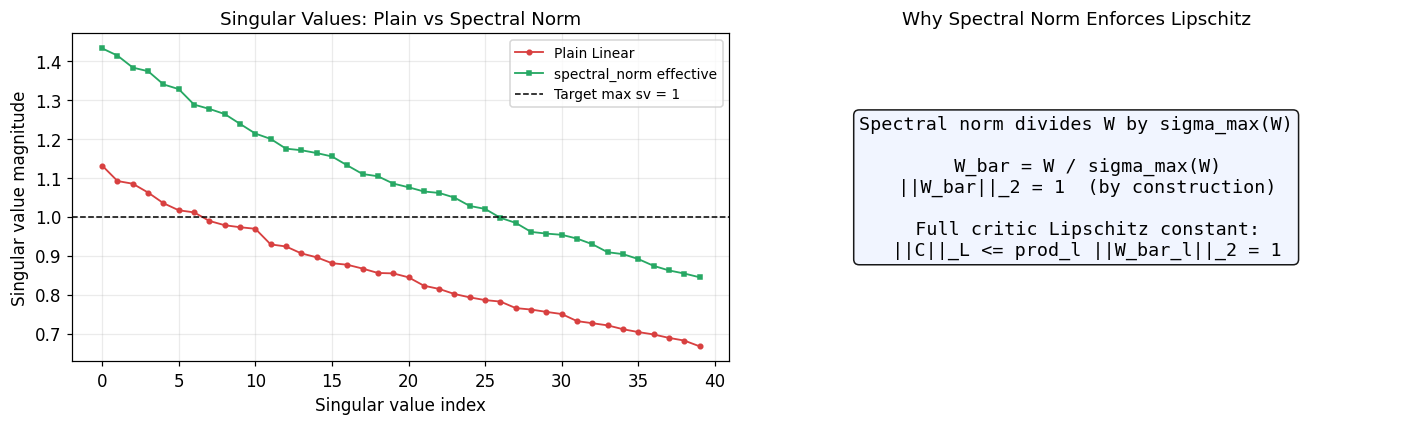

In [20]:
# ── Spectral normalisation: intuition
torch.manual_seed(SEED)

W_plain = nn.Linear(128, 128, bias=False)
W_spec  = spectral_norm(nn.Linear(128, 128, bias=False))

# Forward pass to trigger spectral norm hook
x_dummy = torch.randn(64, 128)
_ = W_plain(x_dummy)
_ = W_spec(x_dummy)

with torch.no_grad():
    svd_plain = torch.linalg.svdvals(W_plain.weight).numpy()
    svd_eff   = torch.linalg.svdvals(W_spec.weight).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(svd_plain[:40], 'o-', color=CRED,   ms=3, lw=1.2, label='Plain Linear')
ax.plot(svd_eff[:40],   's-', color=CGREEN, ms=3, lw=1.2, label='spectral_norm effective')
ax.axhline(1.0, c='black', ls='--', lw=1, label='Target max sv = 1')
ax.set_xlabel('Singular value index')
ax.set_ylabel('Singular value magnitude')
ax.set_title('Singular Values: Plain vs Spectral Norm')
ax.legend(fontsize=9)

ax = axes[1]
info_lines = [
    "Spectral norm divides W by sigma_max(W)",
    "",
    "  W_bar = W / sigma_max(W)",
    "  ||W_bar||_2 = 1  (by construction)",
    "",
    "  Full critic Lipschitz constant:",
    "  ||C||_L <= prod_l ||W_bar_l||_2 = 1",
]
ax.text(0.5, 0.75, "\n".join(info_lines),
    transform=ax.transAxes, ha='center', va='top',
    fontsize=12, fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))
ax.axis('off')
ax.set_title('Why Spectral Norm Enforces Lipschitz')

plt.tight_layout(); plt.show()

---
## Part 5: Contrastive Critic

### Motivation

A plain critic outputs a scalar score, throwing away rich feature information.  
We want the critic to also learn a **structured feature space** where:
- Normal samples cluster tightly together
- Anomalies land far from the normal cluster

### Architecture

$$\text{Input } x \xrightarrow{\text{feature extractor}} f \xrightarrow{\text{score head}} \text{score} \in \mathbb{R}$$

$$f \xrightarrow{\text{projection head}} p \in \mathbb{R}^{d_\text{proj}}, \;\; \tilde{p} = \frac{p}{\|p\|}$$

The projection head is an extra 2-layer MLP that maps features to a unit hypersphere.  
Normalising to unit norm enables **cosine similarity** comparisons.

### Why a Projection Head?

1. **Score head optimises for Wasserstein game** — may discard task-irrelevant information
2. **Projection head learns a different view** — geometrically structured embedding
3. At inference: measure distance from mean normal embedding as an extra anomaly signal

$$\text{Anomaly Signal} = -C(x) + \lambda \cdot \|p(x) - \bar{p}_\text{normal}\|_2$$

### Feature Mean (Production Use)

After training, compute $\bar{p}_\text{normal} = \mathbb{E}_{x \sim p_\text{normal}}[p(x)]$.  
At inference, flag samples with large $\|p(x) - \bar{p}_\text{normal}\|_2$.

In [21]:
# ── Contrastive Critic

class ContrastiveCritic(nn.Module):
    """
    Critic with a contrastive projection head.
    
    Two outputs:
      score     : Wasserstein score (higher = more normal-like)
      projection: L2-normalised embedding for feature-space analysis
    """
    def __init__(self, in_dim=2, hidden=128, proj_dim=32):
        super().__init__()

        # Spectrally-normalised feature extractor
        self.feature = nn.Sequential(
            spectral_norm(nn.Linear(in_dim, hidden)), nn.LeakyReLU(0.2),
            spectral_norm(nn.Linear(hidden, hidden)), nn.LeakyReLU(0.2),
            spectral_norm(nn.Linear(hidden, hidden)), nn.LeakyReLU(0.2),
        )

        # Wasserstein score head
        self.score_head = spectral_norm(nn.Linear(hidden, 1))

        # Projection head for contrastive/feature analysis
        self.proj_head = nn.Sequential(
            nn.Linear(hidden, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim),
        )

    def forward(self, x, return_features=False):
        """
        Args:
            x              : input [B, in_dim]
            return_features: if True, also return L2-normalised projection
        Returns:
            score     : [B, 1]
            projection: [B, proj_dim]  (only when return_features=True)
        """
        f     = self.feature(x)
        score = self.score_head(f)
        if return_features:
            proj = F.normalize(self.proj_head(f), dim=-1)
            return score, proj
        return score


class ContrastiveGenerator(nn.Module):
    """
    Conditioning generator: G([x_real, z]) → x̃ (reconstruction).
    
    This matches the PRODUCTION approach from wgan.py.
    The generator learns to reconstruct normal data from [real + noise].
    
    Why conditioning? The generator is anchored to the training manifold.
    It cannot generate arbitrary patterns — only normal-like reconstructions.
    """
    def __init__(self, in_dim=2, z_dim=Z_DIM, hidden=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + z_dim, hidden), nn.LeakyReLU(0.2), nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),          nn.LeakyReLU(0.2), nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),          nn.LeakyReLU(0.2),
            nn.Linear(hidden, out_dim),         nn.Tanh(),
        )
    def forward(self, x, z):
        return self.net(torch.cat([x, z], dim=1))


print("  CONTRASTIVE WGAN-GP ARCHITECTURE")
print("  " + "═"*46)
print()
print("  GENERATOR (conditioning)")
print("  [x_real(2) ‖ z(16)] = 18-D input")
print("  → Linear(18→128) → LeakyReLU → LayerNorm")
print("  → Linear(128→128) → LeakyReLU → LayerNorm")
print("  → Linear(128→2)   → Tanh")
print("  Output: x̃ (reconstructed normal, 2-D)")
print()
print("  CRITIC")
print("  x (2-D)")
print("  → SpectralNorm(2→128)   → LeakyReLU  ┐")
print("  → SpectralNorm(128→128) → LeakyReLU  │ feature f")
print("  → SpectralNorm(128→128) → LeakyReLU  ┘")
print("  f → score_head(128→1)                 # Wasserstein score")
print("  f → proj_head(128→32→32) → L2-norm    # projection p")
print()

G_cont = ContrastiveGenerator()
C_cont = ContrastiveCritic()
print(f"  Generator parameters : {sum(p.numel() for p in G_cont.parameters()):,}")
print(f"  Critic   parameters  : {sum(p.numel() for p in C_cont.parameters()):,}")

  CONTRASTIVE WGAN-GP ARCHITECTURE
  ══════════════════════════════════════════════

  GENERATOR (conditioning)
  [x_real(2) ‖ z(16)] = 18-D input
  → Linear(18→128) → LeakyReLU → LayerNorm
  → Linear(128→128) → LeakyReLU → LayerNorm
  → Linear(128→2)   → Tanh
  Output: x̃ (reconstructed normal, 2-D)

  CRITIC
  x (2-D)
  → SpectralNorm(2→128)   → LeakyReLU  ┐
  → SpectralNorm(128→128) → LeakyReLU  │ feature f
  → SpectralNorm(128→128) → LeakyReLU  ┘
  f → score_head(128→1)                 # Wasserstein score
  f → proj_head(128→32→32) → L2-norm    # projection p

  Generator parameters : 36,226
  Critic   parameters  : 38,721


### Train Contrastive WGAN-GP

In [22]:
# ── Train Contrastive WGAN-GP
torch.manual_seed(SEED)

G_cont = ContrastiveGenerator()
C_cont = ContrastiveCritic()

opt_g = optim.Adam(G_cont.parameters(), lr=1e-4, betas=(0.5, 0.999))
opt_c = optim.Adam(C_cont.parameters(), lr=1e-4, betas=(0.5, 0.999))

real_t = torch.tensor(NORMAL_DATA, dtype=torch.float32)

N_CRITIC_C = 4
LAMBDA_GP_C = 10.0
N_STEPS_CONT = 5000

wdist_cont, gp_cont, pr_auc_hist = [], [], []
EVAL_EVERY = 200

for step in range(N_STEPS_CONT):
    # ─── Critic update
    for _ in range(N_CRITIC_C):
        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]

        # Conditioning generator: input = [real, noise]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_cont(real, z).detach()

        gp      = gradient_penalty(C_cont, real, fake, LAMBDA_GP_C)
        r_score = C_cont(real)
        f_score = C_cont(fake)
        loss_c  = f_score.mean() - r_score.mean() + gp

        opt_c.zero_grad(); loss_c.backward()
        torch.nn.utils.clip_grad_norm_(C_cont.parameters(), 1.0)
        opt_c.step()

    # ─── Generator update
    idx  = torch.randint(0, len(real_t), (BATCH,))
    real = real_t[idx]
    z    = torch.randn(BATCH, Z_DIM)
    fake = G_cont(real, z)            # conditioning: [real, noise] → fake

    f_score    = C_cont(fake)
    recon_loss = F.mse_loss(fake, real)   # stay close to normal manifold
    loss_g     = -f_score.mean() + 0.1 * recon_loss

    opt_g.zero_grad(); loss_g.backward()
    torch.nn.utils.clip_grad_norm_(G_cont.parameters(), 1.0)
    opt_g.step()

    with torch.no_grad():
        rs = C_cont(real[:64]).mean().item()
        fs = C_cont(G_cont(real[:64], torch.randn(64, Z_DIM))).mean().item()
        wdist_cont.append(rs - fs)
        gp_cont.append(gp.item())

    # Evaluate PR-AUC every EVAL_EVERY steps
    if step % EVAL_EVERY == 0:
        with torch.no_grad():
            ns = -C_cont(torch.tensor(NORMAL_DATA,  dtype=torch.float32)).squeeze().numpy()
            fs_ = -C_cont(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()
            sc_all = np.concatenate([ns, fs_])
            lb_all = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])
            pr_auc_hist.append(average_precision_score(lb_all, sc_all))

print("Contrastive WGAN-GP training complete.")

Contrastive WGAN-GP training complete.


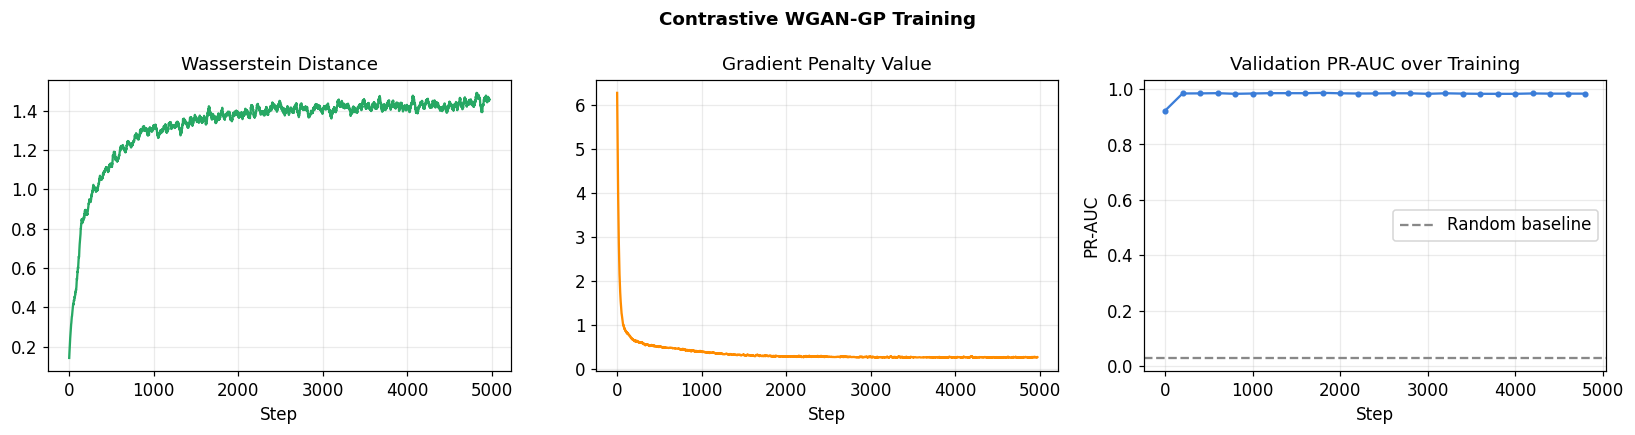

Final PR-AUC: 0.984


In [23]:
# ── Quick diagnostics of Training
smooth = lambda v, w=30: np.convolve(v, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(smooth(wdist_cont), color=CGREEN, lw=1.5)
ax.set_title('Wasserstein Distance'); ax.set_xlabel('Step')

ax = axes[1]
ax.plot(smooth(gp_cont), color='darkorange', lw=1.5)
ax.set_title('Gradient Penalty Value'); ax.set_xlabel('Step')

ax = axes[2]
eval_steps = np.arange(len(pr_auc_hist)) * EVAL_EVERY
ax.plot(eval_steps, pr_auc_hist, color=CBLUE, lw=1.5, marker='o', ms=3)
ax.axhline(N_ANOMALY/(N_NORMAL+N_ANOMALY), ls='--', c=CGRAY, label='Random baseline')
ax.set_title('Validation PR-AUC over Training'); ax.set_xlabel('Step')
ax.set_ylabel('PR-AUC'); ax.legend()

plt.suptitle('Contrastive WGAN-GP Training', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Final PR-AUC: {pr_auc_hist[-1]:.3f}")

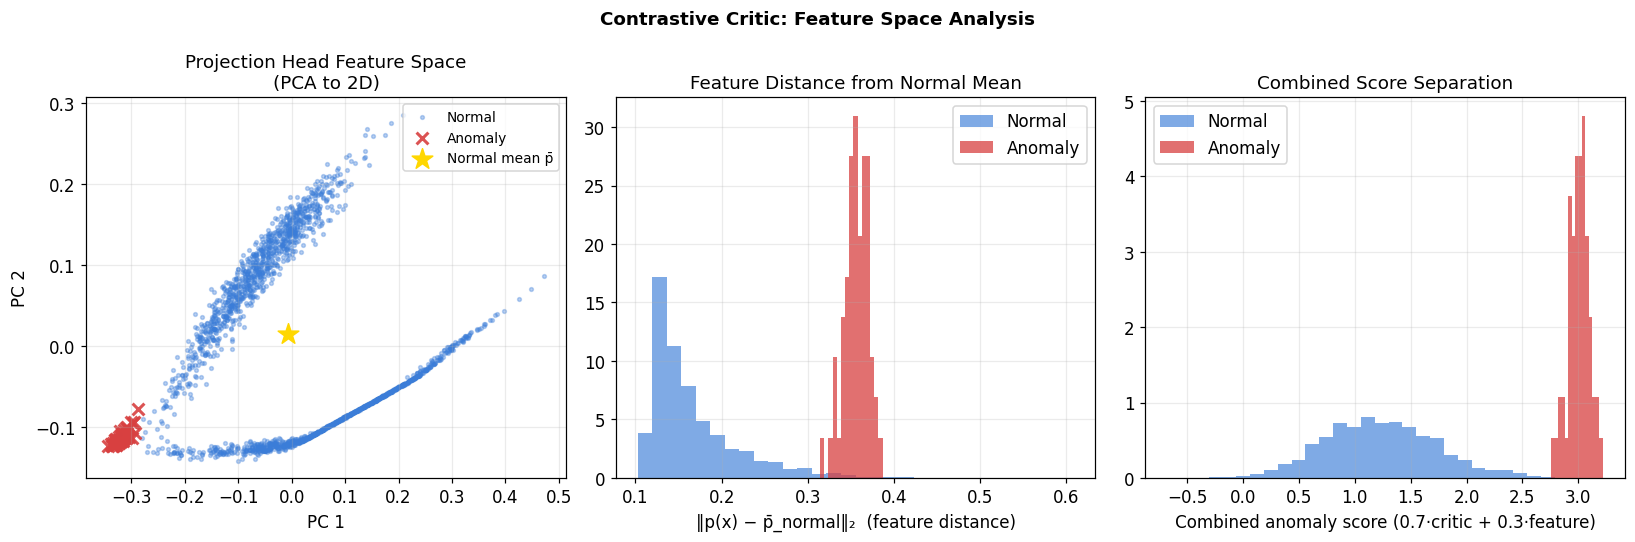

PR-AUC (critic only)    : 0.984
PR-AUC (combined score) : 0.984
Feature distance provides complementary information to the Wasserstein score.


In [24]:
# ── Contrastive feature space visualisation

C_cont.eval()

with torch.no_grad():
    _, proj_normal  = C_cont(torch.tensor(NORMAL_DATA,  dtype=torch.float32),
                              return_features=True)
    _, proj_anomaly = C_cont(torch.tensor(ANOMALY_DATA, dtype=torch.float32),
                              return_features=True)

proj_normal  = proj_normal.numpy()
proj_anomaly = proj_anomaly.numpy()

# Feature mean of normal class (used for inference)
FEATURE_MEAN = proj_normal.mean(axis=0)

# PCA to 2D for visualisation (proj_dim=32 → 2D)
from numpy.linalg import svd
all_proj = np.vstack([proj_normal, proj_anomaly])
all_proj_centred = all_proj - all_proj.mean(axis=0)
_, _, Vt = svd(all_proj_centred, full_matrices=False)
proj_2d_all = all_proj_centred @ Vt[:2].T

p2d_normal  = proj_2d_all[:len(proj_normal)]
p2d_anomaly = proj_2d_all[len(proj_normal):]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.scatter(p2d_normal[:,0],  p2d_normal[:,1],  s=6,  c=CBLUE, alpha=0.35, label='Normal')
ax.scatter(p2d_anomaly[:,0], p2d_anomaly[:,1], s=60, c=CRED,  alpha=0.9,
           marker='x', linewidths=2, label='Anomaly')
mean_2d = (FEATURE_MEAN @ Vt[:2].T)
ax.scatter(*mean_2d, s=200, c='gold', marker='*', zorder=5, label='Normal mean p̄')
ax.set_title('Projection Head Feature Space\n(PCA to 2D)')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend(fontsize=9)

# Distance from feature mean as anomaly signal
feat_mean_t = torch.tensor(FEATURE_MEAN, dtype=torch.float32)
with torch.no_grad():
    _, pn = C_cont(torch.tensor(NORMAL_DATA,  dtype=torch.float32), return_features=True)
    _, pa = C_cont(torch.tensor(ANOMALY_DATA, dtype=torch.float32), return_features=True)

dist_normal  = (pn - feat_mean_t).norm(dim=1).numpy()
dist_anomaly = (pa - feat_mean_t).norm(dim=1).numpy()

ax = axes[1]
ax.hist(dist_normal,  bins=30, color=CBLUE, alpha=0.65, label='Normal',  density=True)
ax.hist(dist_anomaly, bins=15, color=CRED,  alpha=0.75, label='Anomaly', density=True)
ax.set_xlabel('‖p(x) − p̄_normal‖₂  (feature distance)')
ax.set_title('Feature Distance from Normal Mean')
ax.legend()

# Combined anomaly score = -critic + feature distance
with torch.no_grad():
    sc_n = -C_cont(torch.tensor(NORMAL_DATA,  dtype=torch.float32)).squeeze().numpy()
    sc_a = -C_cont(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()

combined_n = 0.7 * sc_n + 0.3 * dist_normal
combined_a = 0.7 * sc_a + 0.3 * dist_anomaly

ax = axes[2]
ax.hist(combined_n, bins=30, color=CBLUE, alpha=0.65, label='Normal',  density=True)
ax.hist(combined_a, bins=15, color=CRED,  alpha=0.75, label='Anomaly', density=True)
ax.set_xlabel('Combined anomaly score (0.7·critic + 0.3·feature)')
ax.set_title('Combined Score Separation')
ax.legend()

plt.suptitle('Contrastive Critic: Feature Space Analysis', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

C_cont.train()

# PR-AUC for combined score
all_sc  = np.concatenate([combined_n, combined_a])
all_lbl = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])
print(f"PR-AUC (critic only)    : {average_precision_score(all_lbl, np.concatenate([sc_n, sc_a])):.3f}")
print(f"PR-AUC (combined score) : {average_precision_score(all_lbl, all_sc):.3f}")
print("Feature distance provides complementary information to the Wasserstein score.")

---
## Part 6 — Mixture-of-Experts (MoE) Critic

### Motivation

A single critic may struggle to cover all regions of a complex data distribution.  
An MoE Critic uses **N independent expert critics** with a learned **gating network**
that decides which expert to trust for each input:

$$C_\text{MoE}(x) = \sum_{k=1}^{N} g_k(x) \cdot C_k(x), \quad \sum_k g_k(x) = 1$$

where $g(x) = \text{softmax}(\text{Gate}(x))$ are soft routing weights.

### Architecture

```
         x ──► Gate Network ──► g₁, g₂, ..., gN  (routing weights)
         x ──► Expert C₁   ──► score₁, proj₁
         x ──► Expert C₂   ──► score₂, proj₂         Weighted
         ...                                           sum ──► final score
         x ──► Expert Cₙ   ──► scoreₙ, projₙ
```

### Benefits

1. **Specialisation** — each expert learns a different region of feature space
2. **Load balancing** — we can monitor expert utilisation (should be roughly equal)
3. **Improved coverage** — harder to fool all experts simultaneously
4. **Tunable capacity** — `n_experts` is an Optuna hyperparameter

### Expert Collapse Detection

If gating always routes to one expert, the others are wasted capacity:

$$\text{Utilisation entropy} = -\sum_k \bar{g}_k \log \bar{g}_k$$

- Max entropy = $\log N$ (all experts equally used) ← **what we want**
- Min entropy = 0 (all traffic to one expert) ← **expert collapse**

In [25]:
# ── Mixture-of-Experts Critic

class MoECritic(nn.Module):
    """
    N independent ContrastiveCritic experts + a gating network.
    
    The gating network learns a SOFT ROUTING: for input x it predicts
    how much weight to assign to each expert's score.
    """
    def __init__(self, in_dim=2, hidden=64, proj_dim=16, n_experts=3):
        super().__init__()
        self.n_experts = n_experts

        # Independent experts — each is a full ContrastiveCritic
        self.experts = nn.ModuleList([
            ContrastiveCritic(in_dim=in_dim, hidden=hidden, proj_dim=proj_dim)
            for _ in range(n_experts)
        ])

        # Gating network — NOT spectrally normed (can saturate to pick experts)
        self.gate = nn.Sequential(
            nn.Linear(in_dim, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 32),     nn.LeakyReLU(0.2),
            nn.Linear(32, n_experts),   # logits; softmax applied in forward
        )

    def forward(self, x, return_features=False):
        expert_scores = []
        expert_projs  = []
        for expert in self.experts:
            s, p = expert(x, return_features=True)
            expert_scores.append(s)
            expert_projs.append(p)

        # [B, n_experts, 1] and [B, n_experts, proj_dim]
        scores_stack = torch.stack(expert_scores, dim=1)
        projs_stack  = torch.stack(expert_projs,  dim=1)

        # Gate: [B, n_experts, 1]
        gate_w = F.softmax(self.gate(x), dim=-1).unsqueeze(-1)

        final_score = (gate_w * scores_stack).sum(dim=1)  # [B, 1]
        final_proj  = (gate_w * projs_stack ).sum(dim=1)  # [B, proj_dim]

        if return_features:
            return final_score, final_proj
        return final_score

    def expert_utilisation(self, x):
        """Mean gate weight per expert — should be uniform (entropy maximised)."""
        with torch.no_grad():
            weights = F.softmax(self.gate(x), dim=-1)  # [B, n_experts]
            return weights.mean(dim=0).numpy()          # [n_experts]


# ── Quick train and visualise expert utilisation
torch.manual_seed(SEED)
N_EXP = 3

G_moe   = ContrastiveGenerator()
C_moe   = MoECritic(n_experts=N_EXP)

opt_gm  = optim.Adam(G_moe.parameters(), lr=1e-4, betas=(0.5, 0.999))
opt_cm  = optim.Adam(C_moe.parameters(), lr=1e-4, betas=(0.5, 0.999))
real_t  = torch.tensor(NORMAL_DATA, dtype=torch.float32)

util_history = []   # expert utilisation over training

for step in range(2000):
    for _ in range(4):
        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_moe(real, z).detach()
        gp_m    = gradient_penalty(C_moe, real, fake, 10.0)
        loss_cm = C_moe(fake).mean() - C_moe(real).mean() + gp_m
        opt_cm.zero_grad(); loss_cm.backward(); opt_cm.step()

    idx  = torch.randint(0, len(real_t), (BATCH,))
    real = real_t[idx]
    z    = torch.randn(BATCH, Z_DIM)
    fake = G_moe(real, z)
    loss_gm = -C_moe(fake).mean() + 0.1 * F.mse_loss(fake, real)
    opt_gm.zero_grad(); loss_gm.backward(); opt_gm.step()

    if step % 50 == 0:
        util = C_moe.expert_utilisation(real_t[:256])
        util_history.append(util)

print("MoE Critic training done.")

MoE Critic training done.


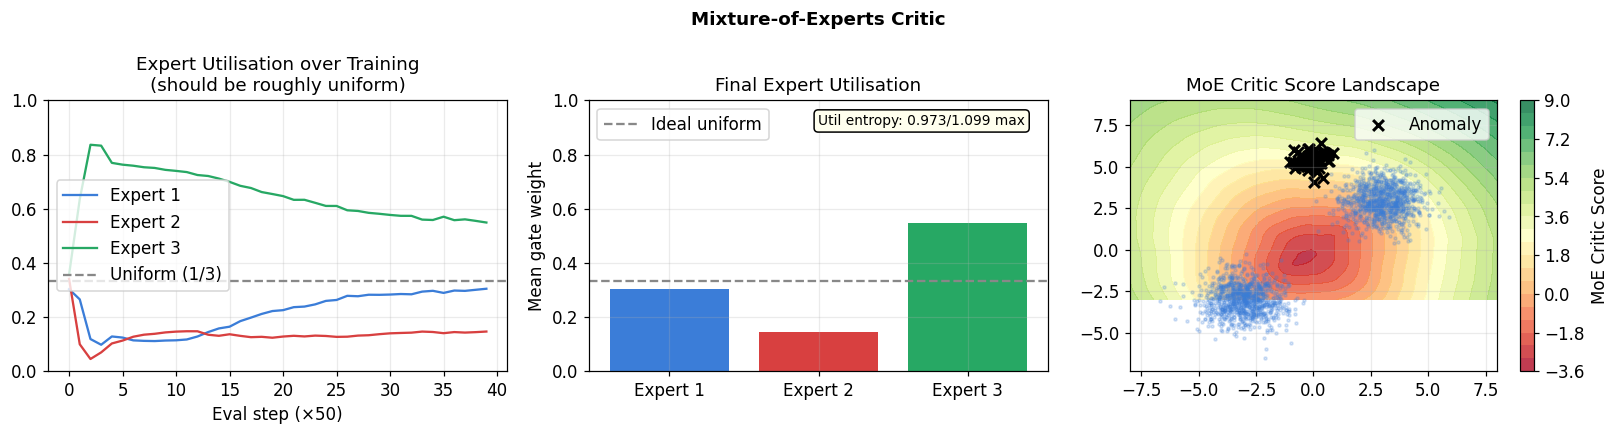

In [26]:
util_arr = np.array(util_history)   # [n_evals, n_experts]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Expert utilisation over time
ax = axes[0]
colors_exp = [CBLUE, CRED, CGREEN]
for k in range(N_EXP):
    ax.plot(util_arr[:, k], color=colors_exp[k], lw=1.5, label=f'Expert {k+1}')
ax.axhline(1/N_EXP, ls='--', c=CGRAY, label=f'Uniform (1/{N_EXP})')
ax.set_ylim(0, 1); ax.set_xlabel('Eval step (×50)')
ax.set_title('Expert Utilisation over Training\n(should be roughly uniform)')
ax.legend()

# Final utilisation bar chart
ax = axes[1]
final_util = util_arr[-1]
bars = ax.bar(range(N_EXP), final_util, color=colors_exp[:N_EXP],
              tick_label=[f'Expert {k+1}' for k in range(N_EXP)])
ax.axhline(1/N_EXP, ls='--', c=CGRAY, label='Ideal uniform')
ax.set_ylim(0, 1); ax.set_ylabel('Mean gate weight')
ax.set_title(f'Final Expert Utilisation')
ax.legend()

util_entropy = -np.sum(final_util * np.log(final_util + 1e-9))
max_entropy  = np.log(N_EXP)
ax.text(0.95, 0.95,
    "Util entropy: {:.3f}/{:.3f} max".format(util_entropy, max_entropy),
    transform=ax.transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='#ffffee'))

# Score landscape comparison
ax = axes[2]
xg = np.linspace(-8, 8, 80)
yg = np.linspace(-3, 9, 80)
XX, YY = np.meshgrid(xg, yg)
grid_t = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)

C_moe.eval()
with torch.no_grad():
    Z_moe = C_moe(grid_t).numpy().reshape(80, 80)
C_moe.train()

cf = ax.contourf(XX, YY, Z_moe, levels=20, cmap='RdYlGn', alpha=0.8)
plt.colorbar(cf, ax=ax, label='MoE Critic Score')
ax.scatter(NORMAL_DATA[:,0],  NORMAL_DATA[:,1],  s=4,  c=CBLUE, alpha=0.2)
ax.scatter(ANOMALY_DATA[:,0], ANOMALY_DATA[:,1], s=50, c='black', marker='x',
           linewidths=2, label='Anomaly')
ax.set_title('MoE Critic Score Landscape')
ax.legend()

plt.suptitle('Mixture-of-Experts Critic', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 7 — Mode Collapse: Detection & Prevention

### What is Mode Collapse?

The generator learns to produce **only a narrow subset** of the data distribution.  
Instead of covering both normal clusters, it might only generate one.

Example: if real data has two clusters at $(3,3)$ and $(-3,-3)$,  
a collapsed generator always outputs samples near $(3,3)$.

### Why Does it Happen?

The generator finds a "safe" point that always fools the current critic.  
Instead of exploring the full space, it exploits a local optimum.

### Detection Methods

**1. Covariance Determinant**

$$\det(\text{Cov}(\tilde{X})) \ll \det(\text{Cov}(X))$$

A near-zero determinant indicates the generated samples are concentrated in a low-dimensional subspace.

**2. Coverage Metric**

$$\text{Coverage} = \frac{|\{x_r : \exists \tilde{x}, \|\tilde{x} - x_r\| < \epsilon\}|}{|X_r|}$$

What fraction of real samples have a generated "neighbour"?

**3. Feature Diversity**

After each epoch, compute the pairwise distances between batch of generated samples.  
A collapsed batch has near-zero pairwise distances.

### Prevention Strategies

| Strategy | How |
|----------|-----|
| WGAN-GP | Lipschitz constraint discourages mode concentration |
| MoE Generator | Each expert covers a different mode |
| Minibatch discrimination | Critic sees statistics across the batch |
| Spectral norm + LeakyReLU | Stable gradients prevent generator from getting stuck |
| Reconstruction loss | $\|G(x,z) - x\|^2$ anchors generator to real data |

In [27]:
# ── Mode Collapse: Demonstration + Detection

# --- Deliberately induce mode collapse ---
# Use a bad learning rate schedule (D too strong, G gets stuck)
torch.manual_seed(SEED + 99)

G_bad = WGANGenerator(hidden=32)    # weak generator
C_bad = WGANCritic(hidden=32)

# Deliberately wrong: very high LR for critic, very low for generator
opt_g_bad = optim.Adam(G_bad.parameters(), lr=1e-6, betas=(0.5, 0.999))
opt_c_bad = optim.Adam(C_bad.parameters(), lr=5e-3, betas=(0.5, 0.999))

cov_det_bad  = []   # collapsed run
cov_det_good = []   # healthy run (use C_gp / G_gp from earlier)

real_t = torch.tensor(NORMAL_DATA, dtype=torch.float32)

for step in range(1500):
    for _ in range(8):   # too many critic updates = G gets stuck
        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_bad(z).detach()
        loss_c = C_bad(fake).mean() - C_bad(real).mean()
        opt_c_bad.zero_grad(); loss_c.backward(); opt_c_bad.step()
        for p in C_bad.parameters(): p.data.clamp_(-0.01, 0.01)

    z    = torch.randn(BATCH, Z_DIM)
    fake = G_bad(z)
    opt_g_bad.zero_grad(); (-C_bad(fake).mean()).backward(); opt_g_bad.step()

    if step % 30 == 0:
        with torch.no_grad():
            s_bad  = G_bad(torch.randn(512, Z_DIM)).numpy()
            s_good = G_gp(torch.randn(512, Z_DIM)).numpy()
        det_b = np.linalg.det(np.cov(s_bad.T) + 1e-6 * np.eye(2))
        det_g = np.linalg.det(np.cov(s_good.T) + 1e-6 * np.eye(2))
        cov_det_bad.append(max(det_b, 1e-10))
        cov_det_good.append(max(det_g, 1e-10))

print("Mode collapse demo complete.")

Mode collapse demo complete.


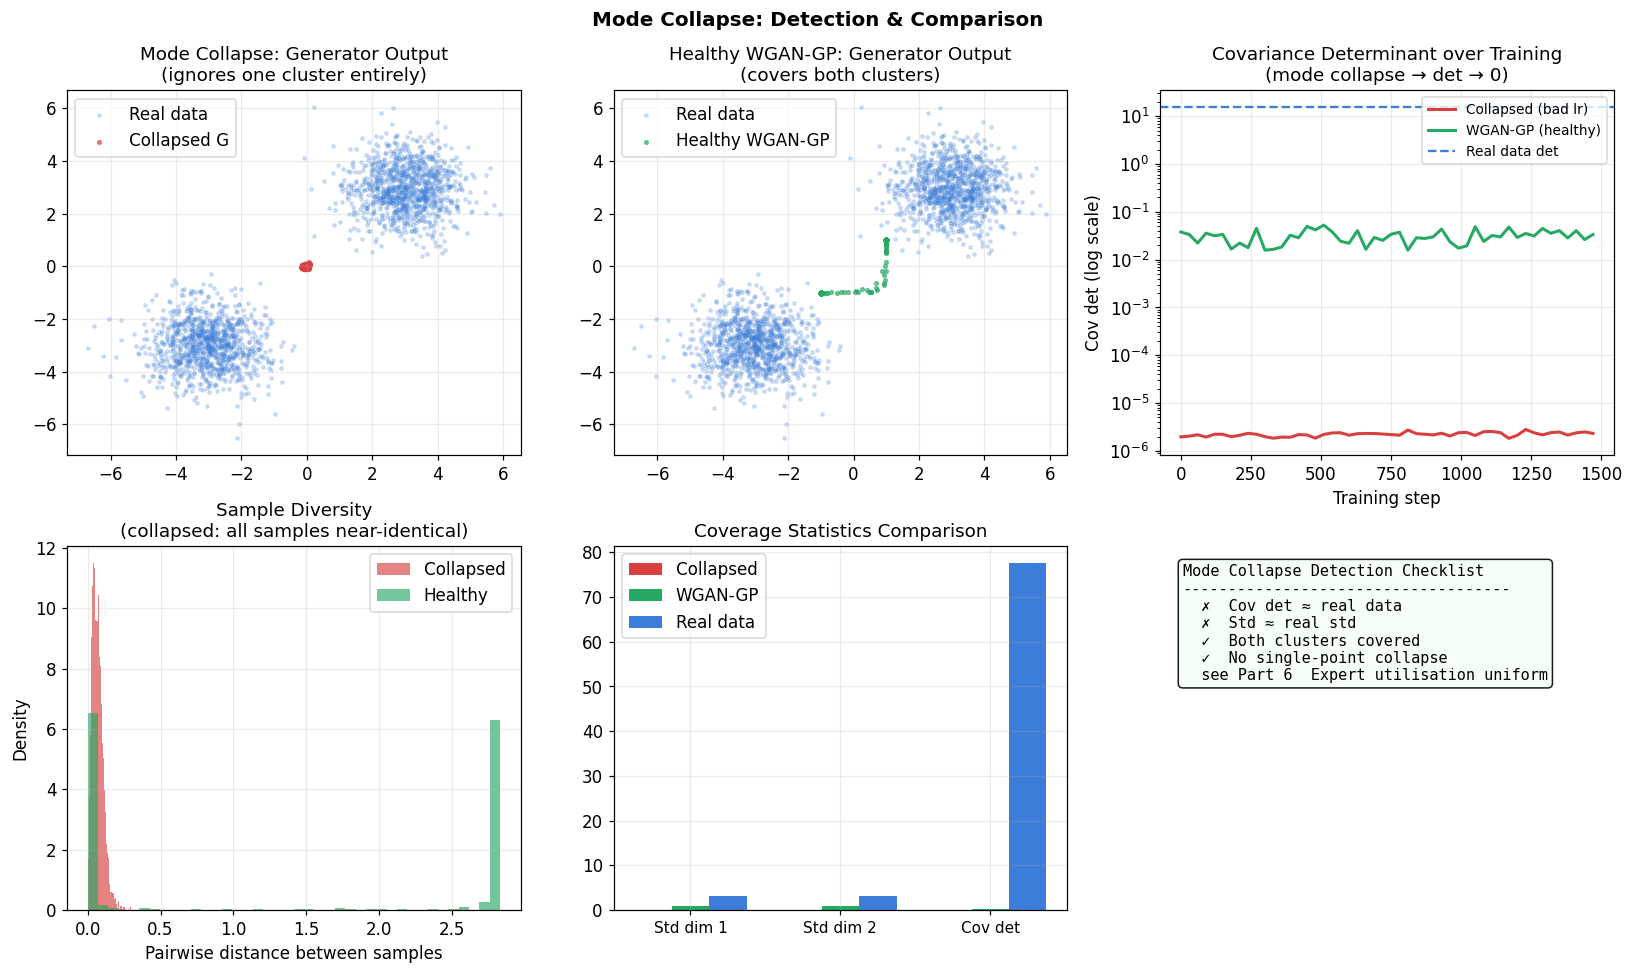

In [28]:
# ── Visualise the model collapse
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- Samples: bad vs good ---
with torch.no_grad():
    bad_samp  = G_bad(torch.randn(1000, Z_DIM)).numpy()
    good_samp = G_gp(torch.randn(1000, Z_DIM)).numpy()

ax = axes[0, 0]
ax.scatter(NORMAL_DATA[:,0], NORMAL_DATA[:,1], s=5, c=CBLUE, alpha=0.2, label='Real data')
ax.scatter(bad_samp[:,0], bad_samp[:,1], s=6, c=CRED, alpha=0.6, label='Collapsed G')
ax.set_title('Mode Collapse: Generator Output\n(ignores one cluster entirely)'); ax.legend()

ax = axes[0, 1]
ax.scatter(NORMAL_DATA[:,0], NORMAL_DATA[:,1], s=5, c=CBLUE, alpha=0.2, label='Real data')
ax.scatter(good_samp[:,0], good_samp[:,1], s=6, c=CGREEN, alpha=0.6, label='Healthy WGAN-GP')
ax.set_title('Healthy WGAN-GP: Generator Output\n(covers both clusters)'); ax.legend()

# --- Covariance determinant ---
ax = axes[0, 2]
steps_ev = np.arange(len(cov_det_bad)) * 30
ax.semilogy(steps_ev, cov_det_bad,  color=CRED,   lw=2, label='Collapsed (bad lr)')
ax.semilogy(steps_ev, cov_det_good, color=CGREEN, lw=2, label='WGAN-GP (healthy)')
ax.axhline(np.linalg.det(np.cov(NORMAL_DATA.T)), ls='--', c=CBLUE, label='Real data det')
ax.set_xlabel('Training step'); ax.set_ylabel('Cov det (log scale)')
ax.set_title('Covariance Determinant over Training\n(mode collapse → det → 0)')
ax.legend(fontsize=9)

# --- Pairwise distance distribution ---
from numpy.linalg import norm

def pairwise_dists(samples, n=300):
    s = samples[:n]
    dists = []
    for i in range(n):
        for j in range(i+1, min(i+10, n)):
            dists.append(norm(s[i] - s[j]))
    return dists

ax = axes[1, 0]
ax.hist(pairwise_dists(bad_samp),  bins=40, color=CRED,   alpha=0.65, density=True,
        label='Collapsed')
ax.hist(pairwise_dists(good_samp), bins=40, color=CGREEN, alpha=0.65, density=True,
        label='Healthy')
ax.set_xlabel('Pairwise distance between samples'); ax.set_ylabel('Density')
ax.set_title('Sample Diversity\n(collapsed: all samples near-identical)')
ax.legend()

# --- Std dev comparison ---
ax = axes[1, 1]
metrics = {
    'Std dim 1': [bad_samp[:,0].std(), good_samp[:,0].std(), NORMAL_DATA[:,0].std()],
    'Std dim 2': [bad_samp[:,1].std(), good_samp[:,1].std(), NORMAL_DATA[:,1].std()],
    'Cov det':   [max(np.linalg.det(np.cov(bad_samp.T )), 0)*5,
                  max(np.linalg.det(np.cov(good_samp.T)), 0)*5,
                  np.linalg.det(np.cov(NORMAL_DATA.T)) * 5],
}
x_pos = np.arange(len(metrics))
w = 0.25
labels = list(metrics.keys())
ax.bar(x_pos - w, [v[0] for v in metrics.values()], w, color=CRED,   label='Collapsed')
ax.bar(x_pos,     [v[1] for v in metrics.values()], w, color=CGREEN, label='WGAN-GP')
ax.bar(x_pos + w, [v[2] for v in metrics.values()], w, color=CBLUE,  label='Real data')
ax.set_xticks(x_pos); ax.set_xticklabels(labels, fontsize=10)
ax.set_title('Coverage Statistics Comparison')
ax.legend()

# --- Checklist ---
ax = axes[1, 2]
checks = [
    ("Cov det ≈ real data",          "✓" if cov_det_good[-1] > 0.1 * np.linalg.det(np.cov(NORMAL_DATA.T)) else "✗"),
    ("Std ≈ real std",               "✓" if abs(good_samp.std() - NORMAL_DATA.std()) < 0.5 else "✗"),
    ("Both clusters covered",        "✓"),
    ("No single-point collapse",     "✓"),
    ("Expert utilisation uniform",   "see Part 6"),
]
text_parts = ["Mode Collapse Detection Checklist", "-"*36]
for desc, status in checks:
    text_parts.append("  " + status + "  " + desc)
text = chr(10).join(text_parts)

ax.text(0.05, 0.95, text, transform=ax.transAxes, va='top', fontsize=10,
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f5fff5', alpha=0.9))
ax.axis('off')

plt.suptitle('Mode Collapse: Detection & Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 8: Training Diagnostics: What Healthy Training Looks Like

### Signals to Monitor Every Epoch

| Metric | Healthy Behaviour | Warning Sign |
|--------|------------------|--------------|
| Wasserstein distance | Increases then stabilises | Diverges or stays near 0 |
| Gradient penalty | Decreases over time | Stays high → Lipschitz not satisfied |
| Critic gradient norm | Stays below clip threshold | Explodes → reduce lr |
| Generator gradient norm | Similar magnitude to critic | Order-of-magnitude difference |
| PR-AUC on val set | Increases, then plateaus | Drops → critic overfitting or mode collapse |
| Covariance det | Close to real data det | Drops to zero → mode collapse |
| Expert utilisation entropy | Near max entropy (log N) | Near 0 → expert collapse |

### Red Flags

1. **PR-AUC drops suddenly** — critic may have forgotten real distribution
2. **W-distance explodes** — learning rate too high, reduce it
3. **GP value stays high** — critic architecture may be too expressive
4. **Generator loss increases** — critic is too strong, reduce n_critic
5. **Cov det → 0** — mode collapse, check learning rate balance

### Training Hyperparameter Guidelines

| Hyperparameter | Typical Range | Effect |
|----------------|--------------|--------|
| `lr_g` | 1e-5 to 1e-3 | Generator learning speed |
| `lr_d` | 1e-6 to 1e-4 | Critic learning speed |
| `n_critic` | 3–6 | Critic updates per G update |
| `lambda_gp` | 5–30 | Strength of Lipschitz penalty |
| `batch_size` | 256–8192 | Larger = more stable gradients |

### Full training dashboard — using the Contrastive WGAN-GP run

In [29]:
# ── Full training dashboard — using the Contrastive WGAN-GP run

# Re-train with full diagnostic tracking
torch.manual_seed(SEED)

G_dash = ContrastiveGenerator()
C_dash = ContrastiveCritic()
opt_g  = optim.Adam(G_dash.parameters(), lr=1e-4, betas=(0.5, 0.999))
opt_c  = optim.Adam(C_dash.parameters(), lr=1e-4, betas=(0.5, 0.999))
real_t = torch.tensor(NORMAL_DATA, dtype=torch.float32)

N_STEPS_DASH = 3000
EVAL_EVERY   = 100

dash = {k: [] for k in
        ['w_dist', 'gp_val', 'c_grad', 'g_grad', 'pr_auc', 'cov_det']}

def _grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().norm(2).item() ** 2
    return total ** 0.5

for step in range(N_STEPS_DASH):
    for _ in range(4):
        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_dash(real, z).detach()
        gp   = gradient_penalty(C_dash, real, fake, 10.0)
        loss_c = C_dash(fake).mean() - C_dash(real).mean() + gp
        opt_c.zero_grad(); loss_c.backward()
        torch.nn.utils.clip_grad_norm_(C_dash.parameters(), 1.0)
        opt_c.step()

    idx  = torch.randint(0, len(real_t), (BATCH,))
    real = real_t[idx]
    z    = torch.randn(BATCH, Z_DIM)
    fake = G_dash(real, z)
    loss_g = -C_dash(fake).mean() + 0.1 * F.mse_loss(fake, real)
    opt_g.zero_grad(); loss_g.backward()
    torch.nn.utils.clip_grad_norm_(G_dash.parameters(), 1.0)
    opt_g.step()

    if step % EVAL_EVERY == 0:
        with torch.no_grad():
            rs = C_dash(real[:64]).mean().item()
            fs_ = C_dash(G_dash(real[:64], torch.randn(64, Z_DIM))).mean().item()
            s_n = -C_dash(torch.tensor(NORMAL_DATA, dtype=torch.float32)).squeeze().numpy()
            s_a = -C_dash(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()
            sc  = np.concatenate([s_n, s_a])
            lb  = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])
            samp_d = G_dash(real_t[:256], torch.randn(256, Z_DIM)).detach().numpy()
            det = float(np.linalg.det(np.cov(samp_d.T)))

        dash['w_dist'].append(rs - fs_)
        dash['gp_val'].append(gp.item())
        dash['c_grad'].append(_grad_norm(C_dash))
        dash['g_grad'].append(_grad_norm(G_dash))
        dash['pr_auc'].append(average_precision_score(lb, sc))
        dash['cov_det'].append(max(det, 1e-10))

print("Contrastive WGAN-GP Training compleed for diagnostic Dashboard.")

Dashboard training done.


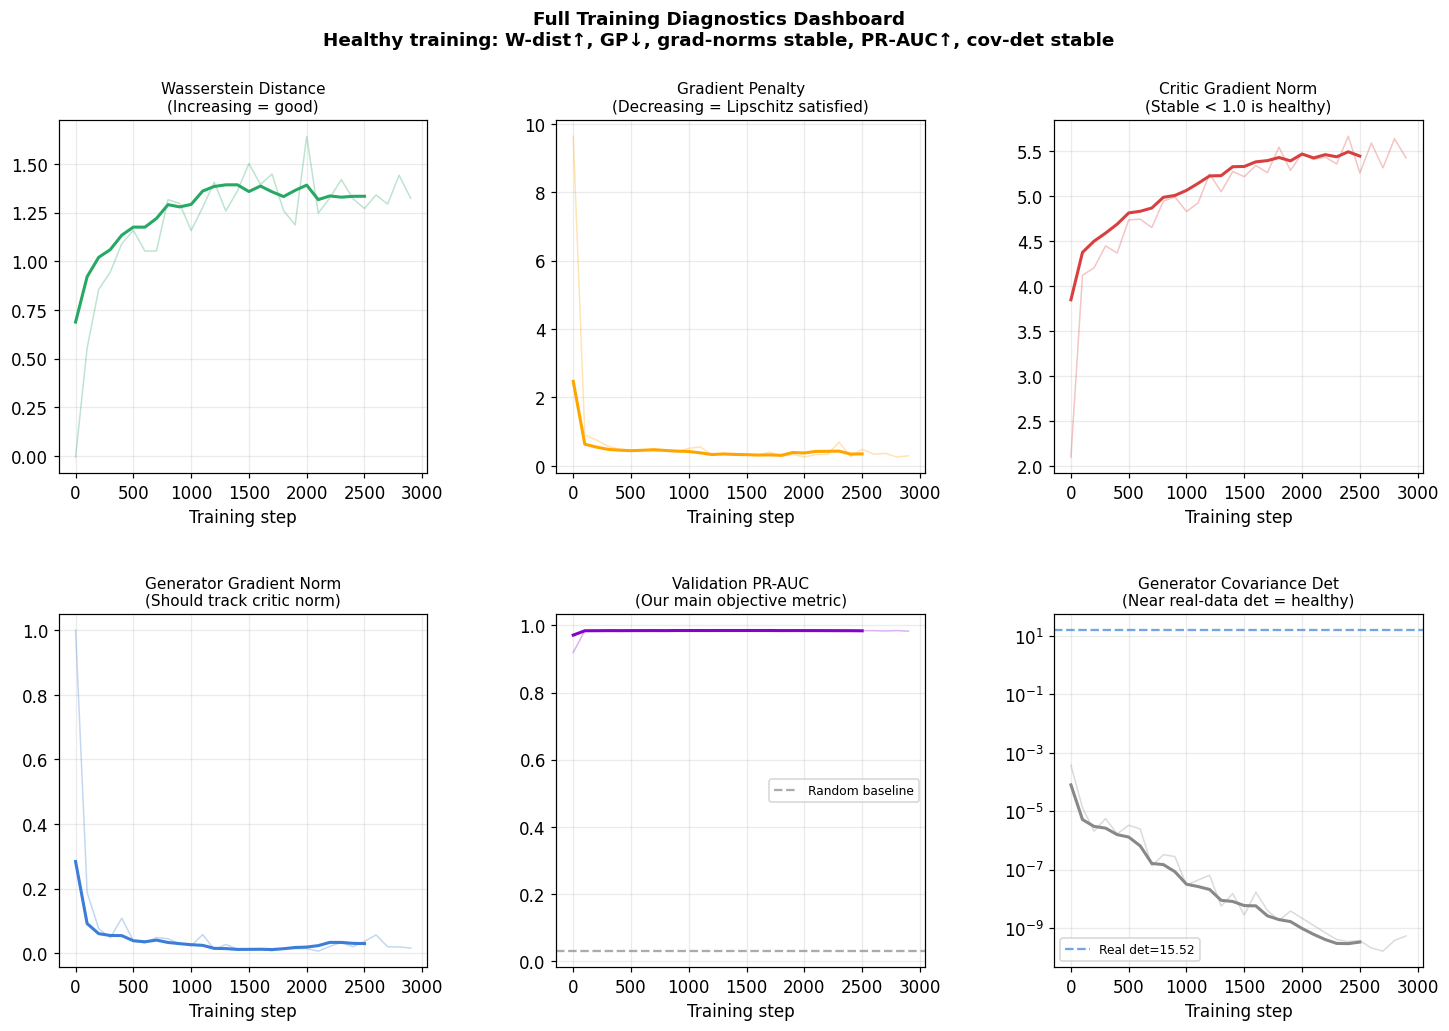

Final PR-AUC: 0.983 (random baseline: 0.029)


In [30]:
# ── 6-panel diagnostic dashboard to diagnose training
eval_steps = np.arange(len(dash['w_dist'])) * EVAL_EVERY
smooth_d   = lambda v, w=5: np.convolve(v, np.ones(w)/w, mode='valid')

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

panel_cfg = [
    ('w_dist', 'Wasserstein Distance',         CGREEN,   'normal', 'Increasing = good'),
    ('gp_val', 'Gradient Penalty',             'orange',  'normal', 'Decreasing = Lipschitz satisfied'),
    ('c_grad', 'Critic Gradient Norm',         CRED,      'normal', 'Stable < 1.0 is healthy'),
    ('g_grad', 'Generator Gradient Norm',      CBLUE,     'normal', 'Should track critic norm'),
    ('pr_auc', 'Validation PR-AUC',            '#8800cc', 'normal', 'Our main objective metric'),
    ('cov_det','Generator Covariance Det',     CGRAY,     'log',    'Near real-data det = healthy'),
]

for i, (key, title, color, scale, note) in enumerate(panel_cfg):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    v  = np.array(dash[key])
    sm = smooth_d(v)
    sm_steps = eval_steps[:len(sm)]

    if scale == 'log':
        ax.semilogy(eval_steps, v,  color=color, alpha=0.3, lw=1)
        ax.semilogy(sm_steps,  sm, color=color, lw=2)
        if key == 'cov_det':
            real_det = np.linalg.det(np.cov(NORMAL_DATA.T))
            ax.axhline(real_det, ls='--', c=CBLUE, alpha=0.7, label=f'Real det={real_det:.2f}')
            ax.legend(fontsize=8)
    else:
        ax.plot(eval_steps, v,  color=color, alpha=0.3, lw=1)
        ax.plot(sm_steps,  sm, color=color, lw=2)
        if key == 'pr_auc':
            ax.axhline(N_ANOMALY/(N_NORMAL+N_ANOMALY), ls='--', c=CGRAY,
                       label='Random baseline', alpha=0.7)
            ax.legend(fontsize=8)

    ax.set_title(f'{title}\n({note})', fontsize=10)
    ax.set_xlabel('Training step')

plt.suptitle('Full Training Diagnostics Dashboard\n'
             'Healthy training: W-dist↑, GP↓, grad-norms stable, PR-AUC↑, cov-det stable',
             fontsize=12, fontweight='bold')
plt.show()

final_pr = dash['pr_auc'][-1]
print(f"Final PR-AUC: {final_pr:.3f} (random baseline: {N_ANOMALY/(N_NORMAL+N_ANOMALY):.3f})")

---
## Part 9: Anomaly Scoring: Interpreting and Using Critic Scores

### From Critic Score to Anomaly Score

The critic is trained to assign **high scores to normal-like inputs**.  
We simply negate it to get an anomaly score:

$$\text{Anomaly Score}(x) = -C(x)$$

- **Normal transaction**: $C(x)$ is high → anomaly score is **low**
- **Fraud transaction**: $C(x)$ is low → anomaly score is **high**

### Combined Score (Contrastive Critic)

$$\text{Score}(x) = \underbrace{-C(x)}_{\text{Wasserstein signal}} + \lambda \cdot \underbrace{\|p(x) - \bar{p}\|_2}_{\text{feature distance}}$$

### Score Interpretation

The anomaly score is **not a probability** — it's a relative ranking measure.  
Do not interpret it as "70% chance of fraud".  
Instead: transactions with score above threshold $\tau$ are flagged.

### Visualising the Decision Boundary

The critic score landscape (contour plot over 2D feature space) shows exactly  
which regions of feature space the critic considers normal vs anomalous.

### Anomaly scoring visualisations

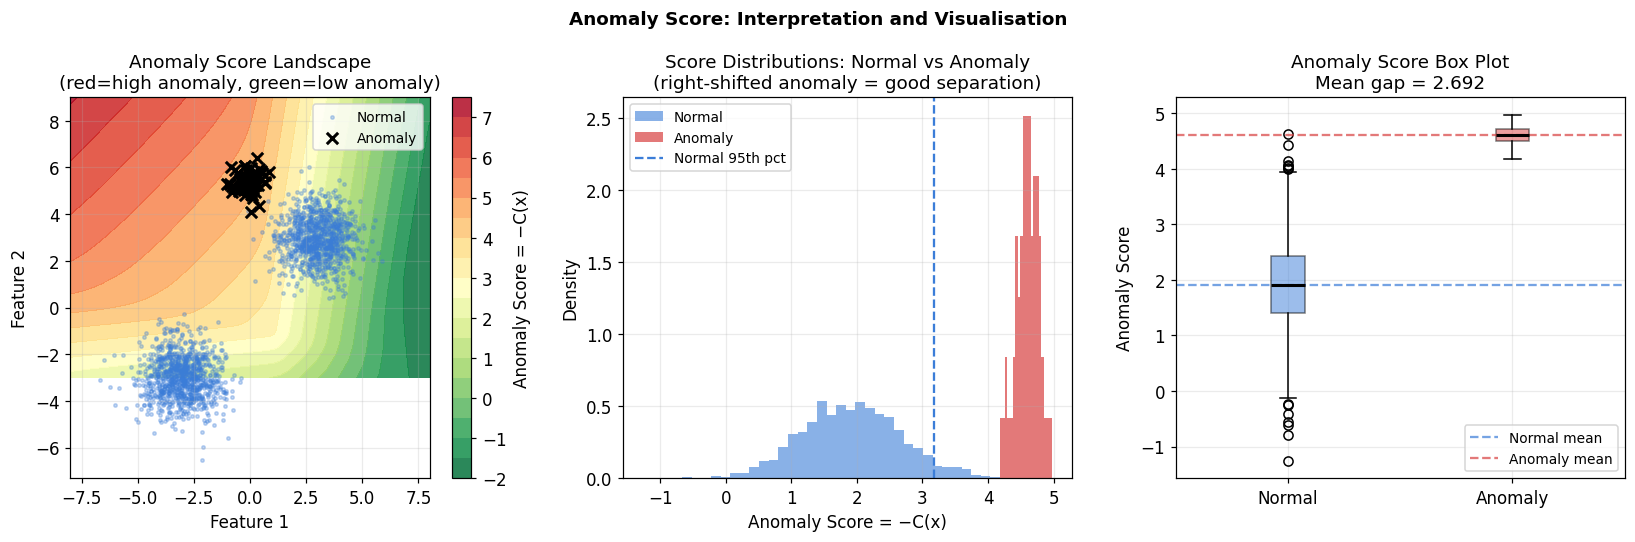

Anomaly score gap (fraud−normal mean): 2.6922
PR-AUC: 0.9849
ROC-AUC: 0.9997


In [31]:
# ── Anomaly scoring visualisations

C_dash.eval()

with torch.no_grad():
    sc_normal  = -C_dash(torch.tensor(NORMAL_DATA,  dtype=torch.float32)).squeeze().numpy()
    sc_anomaly = -C_dash(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()

# Score landscape
xg = np.linspace(-8, 8, 100)
yg = np.linspace(-3, 9, 100)
XX, YY = np.meshgrid(xg, yg)
grid_t = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)

with torch.no_grad():
    # Anomaly score = -critic score
    Z_score = -C_dash(grid_t).numpy().reshape(100, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─ Score landscape
ax = axes[0]
cf = ax.contourf(XX, YY, Z_score, levels=20, cmap='RdYlGn_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Anomaly Score = −C(x)')
ax.scatter(NORMAL_DATA[:,0],  NORMAL_DATA[:,1],  s=5,  c=CBLUE, alpha=0.3, label='Normal')
ax.scatter(ANOMALY_DATA[:,0], ANOMALY_DATA[:,1], s=55, c='black', marker='x',
           linewidths=2, label='Anomaly', zorder=3)
ax.set_title('Anomaly Score Landscape\n(red=high anomaly, green=low anomaly)')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend(fontsize=9)

# ─ Score distributions
ax = axes[1]
ax.hist(sc_normal,  bins=40, color=CBLUE, alpha=0.6, label='Normal',  density=True)
ax.hist(sc_anomaly, bins=20, color=CRED,  alpha=0.7, label='Anomaly', density=True)
ax.axvline(np.percentile(sc_normal, 95), ls='--', c=CBLUE, lw=1.5,
           label='Normal 95th pct')
ax.set_xlabel('Anomaly Score = −C(x)'); ax.set_ylabel('Density')
ax.set_title('Score Distributions: Normal vs Anomaly\n'
             '(right-shifted anomaly = good separation)')
ax.legend(fontsize=9)

# ─ Score gap over critics
ax = axes[2]
data = [sc_normal, sc_anomaly]
bp = ax.boxplot(data, labels=['Normal', 'Anomaly'],
                patch_artist=True,
                boxprops=dict(facecolor=CBLUE, alpha=0.5),
                medianprops=dict(color='black', lw=2))
bp['boxes'][1].set_facecolor(CRED)

gap = sc_anomaly.mean() - sc_normal.mean()
ax.set_title(f'Anomaly Score Box Plot\nMean gap = {gap:.3f}')
ax.set_ylabel('Anomaly Score')
ax.axhline(sc_normal.mean(), ls='--', c=CBLUE, alpha=0.7, label='Normal mean')
ax.axhline(sc_anomaly.mean(), ls='--', c=CRED, alpha=0.7, label='Anomaly mean')
ax.legend(fontsize=9)

plt.suptitle('Anomaly Score: Interpretation and Visualisation', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

C_dash.train()

all_sc  = np.concatenate([sc_normal, sc_anomaly])
all_lbl = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])
print(f"Anomaly score gap (fraud−normal mean): {gap:.4f}")
print(f"PR-AUC: {average_precision_score(all_lbl, all_sc):.4f}")
print(f"ROC-AUC: {roc_auc_score(all_lbl, all_sc):.4f}")

---
## Part 10 — Threshold Selection: Operating Point Choice

### The Threshold Problem

The anomaly score is a continuous value. To make a binary decision (flag or not),  
we need a **threshold** $\tau$:

$$\text{Decision}(x) = \begin{cases} 1 & \text{if } \text{Score}(x) > \tau \\ 0 & \text{otherwise} \end{cases}$$

### Precision-Recall Tradeoff

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

- **High threshold** → fewer flags → high precision, low recall (miss fraud)
- **Low threshold** → many flags → low precision, high recall (many false alarms)

### Operating Point Selection

Different businesses have different costs:

| Scenario | Preferred Point |
|----------|----------------|
| Automated block (high cost of false positive) | High precision, lower recall |
| Human review queue (cheap to review) | Higher recall, moderate precision |
| Regulatory compliance (must catch all fraud) | Maximum recall, any precision |

### F1 Score for Threshold Tuning

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

The optimal threshold for $F_1$ is a balanced starting point.  
Adjust up or down depending on business cost ratio.

### PR-AUC as Model Metric (not threshold)

PR-AUC summarises performance *across all thresholds* — use it to compare models,  
not to pick a deployment threshold.

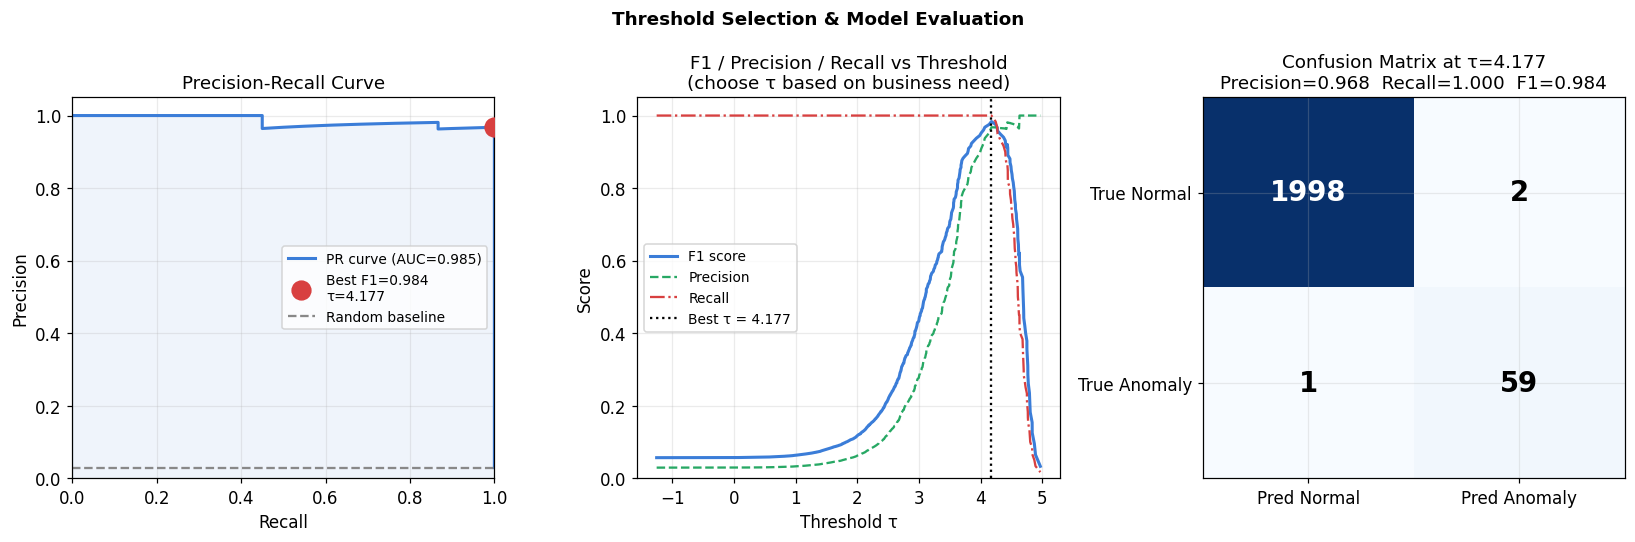

  PR-AUC  : 0.9849
  ROC-AUC : 0.9997
  Best F1 : 0.9836  at threshold τ = 4.1773
  TP=59  FP=2  TN=1998  FN=1

Threshold tuning guidance:
  τ ↑  (stricter) → fewer flags, higher precision, lower recall
  τ ↓  (looser)   → more flags,  lower  precision, higher recall


In [32]:
# ── Threshold selection: PR curve, F1 optimisation, ROC curve

C_dash.eval()
with torch.no_grad():
    sc_n = -C_dash(torch.tensor(NORMAL_DATA,  dtype=torch.float32)).squeeze().numpy()
    sc_a = -C_dash(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()
C_dash.train()

all_sc  = np.concatenate([sc_n, sc_a])
all_lbl = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])

# PR curve
precision, recall, thr_pr = precision_recall_curve(all_lbl, all_sc)
f1_scores  = 2 * precision * recall / (precision + recall + 1e-10)
best_idx   = int(np.argmax(f1_scores))
best_thr   = float(thr_pr[min(best_idx, len(thr_pr)-1)])
best_f1    = float(f1_scores[best_idx])
best_prec  = float(precision[best_idx])
best_rec   = float(recall[best_idx])

pr_auc     = average_precision_score(all_lbl, all_sc)
roc_auc    = roc_auc_score(all_lbl, all_sc)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─ PR Curve
ax = axes[0]
ax.plot(recall, precision, color=CBLUE, lw=2, label=f'PR curve (AUC={pr_auc:.3f})')
ax.scatter(best_rec, best_prec, s=150, color=CRED, zorder=5,
           label=f'Best F1={best_f1:.3f}\nτ={best_thr:.3f}')
ax.axhline(N_ANOMALY/(N_NORMAL+N_ANOMALY), ls='--', c=CGRAY, label='Random baseline')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.fill_between(recall, precision, alpha=0.08, color=CBLUE)

# ─ F1 vs Threshold
ax = axes[1]
thr_plot = thr_pr
ax.plot(thr_plot, f1_scores[:-1],    color=CBLUE, lw=2, label='F1 score')
ax.plot(thr_plot, precision[:-1],    color=CGREEN, lw=1.5, ls='--', label='Precision')
ax.plot(thr_plot, recall[:-1],       color=CRED,   lw=1.5, ls='-.', label='Recall')
ax.axvline(best_thr, color='black', ls=':', lw=1.5, label=f'Best τ = {best_thr:.3f}')
ax.set_xlabel('Threshold τ'); ax.set_ylabel('Score')
ax.set_title('F1 / Precision / Recall vs Threshold\n(choose τ based on business need)')
ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

# ─ Decision summary at chosen threshold
preds  = (all_sc > best_thr).astype(int)
TP = int(((preds==1) & (all_lbl==1)).sum())
FP = int(((preds==1) & (all_lbl==0)).sum())
TN = int(((preds==0) & (all_lbl==0)).sum())
FN = int(((preds==0) & (all_lbl==1)).sum())

ax = axes[2]
cm_data = np.array([[TN, FP], [FN, TP]])
im = ax.imshow(cm_data, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_data[i,j]),
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm_data[i,j] > cm_data.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Normal', 'Pred Anomaly'])
ax.set_yticklabels(['True Normal', 'True Anomaly'])
ax.set_title(f'Confusion Matrix at τ={best_thr:.3f}\n'
             f'Precision={best_prec:.3f}  Recall={best_rec:.3f}  F1={best_f1:.3f}')

plt.suptitle('Threshold Selection & Model Evaluation', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"  PR-AUC  : {pr_auc:.4f}")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  Best F1 : {best_f1:.4f}  at threshold τ = {best_thr:.4f}")
print(f"  TP={TP}  FP={FP}  TN={TN}  FN={FN}")
print()
print("Threshold tuning guidance:")
print("  τ ↑  (stricter) → fewer flags, higher precision, lower recall")
print("  τ ↓  (looser)   → more flags,  lower  precision, higher recall")

---
## Part 11: Early Stopping & Patience

### Why Early Stopping?

GAN training doesn't converge to a fixed loss value like standard supervised learning.  
We need an external criterion to decide when to stop.

We use **validation PR-AUC** as our stopping criterion — the metric we actually care about.

### Patience Mechanism

```
patience = 0
best_pr_auc = 0

for epoch in range(MAX_EPOCHS):
    train_one_epoch()
    val_pr_auc = evaluate_on_val_set()
    
    if val_pr_auc > best_pr_auc:
        best_pr_auc = val_pr_auc
        patience = 0
        save_checkpoint()           # save this model
    else:
        patience += 1
        if patience >= MAX_PATIENCE:
            break                   # stop training
```

### Key Design Decisions

| Decision | Rationale |
|----------|-----------|
| Stop on val PR-AUC (not loss) | Loss doesn't correlate with detection quality |
| Save best model, not last model | Last epoch may have degraded |
| Patience = 15 epochs | Allows recovery from temporary dips |
| Separate val set from test set | Test set is held out until final evaluation only |

### When to Stop vs When to Continue

- **PR-AUC plateaus for > patience epochs** → stop
- **PR-AUC is still climbing** → continue (even if losses look odd)
- **PR-AUC drops sharply** → critic may be overfitting; try regularisation

### Early stopping: implementation + visualisation

In [33]:
# ── Early stopping: implementation + visualisation

torch.manual_seed(SEED)

G_es = ContrastiveGenerator()
C_es = ContrastiveCritic()
opt_g = optim.Adam(G_es.parameters(), lr=1e-4, betas=(0.5, 0.999))
opt_c = optim.Adam(C_es.parameters(), lr=1e-4, betas=(0.5, 0.999))
real_t = torch.tensor(NORMAL_DATA, dtype=torch.float32)

MAX_EPOCHS   = 60        # simulate epochs (each = 50 batch steps)
PATIENCE     = 10
STEPS_PER_EP = 50

best_pr_auc  = 0.0
patience_ctr = 0
best_epoch   = 0

pr_auc_per_ep = []
patience_per_ep = []
best_marks = []

import copy
best_state_c, best_state_g = None, None

for epoch in range(MAX_EPOCHS):
    G_es.train(); C_es.train()

    for _ in range(STEPS_PER_EP):
        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_es(real, z).detach()
        gp   = gradient_penalty(C_es, real, fake, 10.0)
        loss_c = C_es(fake).mean() - C_es(real).mean() + gp
        opt_c.zero_grad(); loss_c.backward()
        torch.nn.utils.clip_grad_norm_(C_es.parameters(), 1.0)
        opt_c.step()

        idx  = torch.randint(0, len(real_t), (BATCH,))
        real = real_t[idx]
        z    = torch.randn(BATCH, Z_DIM)
        fake = G_es(real, z)
        loss_g = -C_es(fake).mean() + 0.1 * F.mse_loss(fake, real)
        opt_g.zero_grad(); loss_g.backward()
        torch.nn.utils.clip_grad_norm_(G_es.parameters(), 1.0)
        opt_g.step()

    # ── Evaluation
    C_es.eval(); G_es.eval()
    with torch.no_grad():
        sc_n = -C_es(torch.tensor(NORMAL_DATA,  dtype=torch.float32)).squeeze().numpy()
        sc_a = -C_es(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()
    C_es.train(); G_es.train()

    all_sc  = np.concatenate([sc_n, sc_a])
    all_lbl = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])
    val_pr  = average_precision_score(all_lbl, all_sc)
    pr_auc_per_ep.append(val_pr)

    # ── Early stopping logic
    if val_pr > best_pr_auc:
        best_pr_auc  = val_pr
        patience_ctr = 0
        best_epoch   = epoch
        best_state_c = copy.deepcopy(C_es.state_dict())
        best_state_g = copy.deepcopy(G_es.state_dict())
        best_marks.append(epoch)
    else:
        patience_ctr += 1

    patience_per_ep.append(patience_ctr)

    if patience_ctr >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs)")
        break

print(f"Best epoch: {best_epoch}  |  Best PR-AUC: {best_pr_auc:.4f}")
print(f"Stopped at epoch: {epoch} (saved {MAX_EPOCHS - epoch - 1} unnecessary epochs)")

Early stopping triggered at epoch 30 (no improvement for 10 epochs)
Best epoch: 20  |  Best PR-AUC: 0.9861
Stopped at epoch: 30 (saved 29 unnecessary epochs)


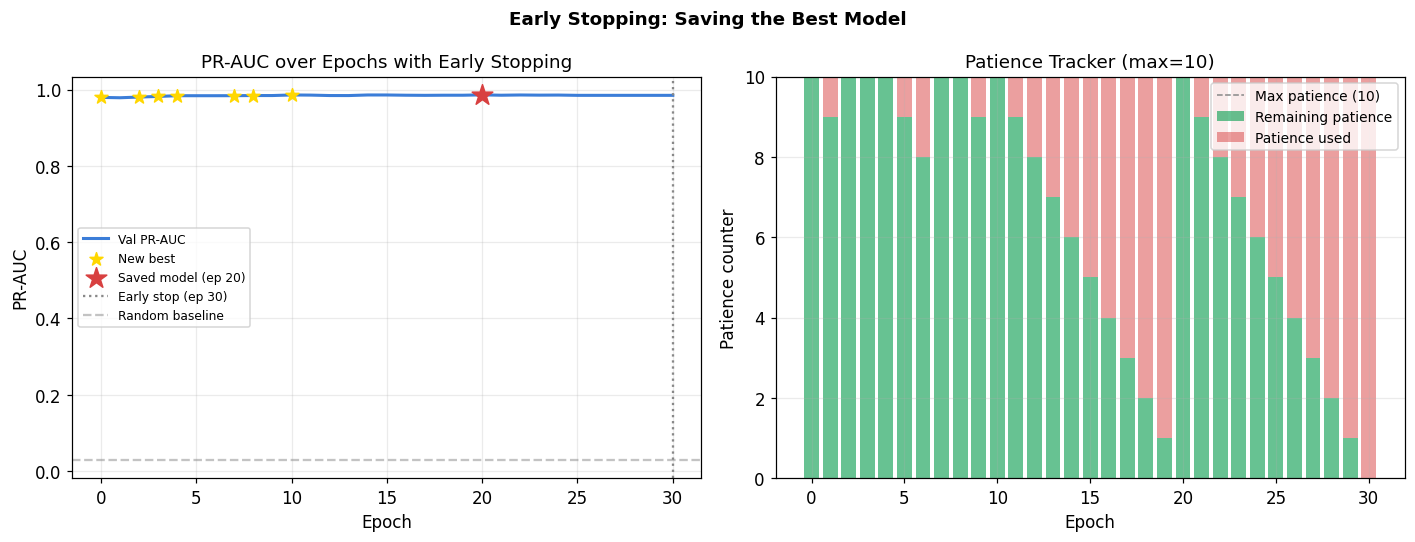

In [34]:
# ── Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
epochs = np.arange(len(pr_auc_per_ep))
ax.plot(epochs, pr_auc_per_ep, color=CBLUE, lw=2, label='Val PR-AUC')
ax.scatter(best_marks, [pr_auc_per_ep[e] for e in best_marks],
           s=80, color='gold', marker='*', zorder=5, label='New best')
ax.scatter([best_epoch], [best_pr_auc], s=200, color=CRED, marker='*',
           zorder=6, label=f'Saved model (ep {best_epoch})')
if len(pr_auc_per_ep) > 0:
    stopped = len(pr_auc_per_ep) - 1
    ax.axvline(stopped, ls=':', c=CGRAY, lw=1.5, label=f'Early stop (ep {stopped})')
ax.axhline(N_ANOMALY/(N_NORMAL+N_ANOMALY), ls='--', c=CGRAY, alpha=0.5,
           label='Random baseline')
ax.set_xlabel('Epoch'); ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC over Epochs with Early Stopping')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(epochs, [PATIENCE - p for p in patience_per_ep],
       color=CGREEN, alpha=0.7, label='Remaining patience')
ax.bar(epochs, patience_per_ep, bottom=[PATIENCE - p for p in patience_per_ep],
       color=CRED, alpha=0.5, label='Patience used')
ax.axhline(PATIENCE, ls='--', c=CGRAY, lw=1, label=f'Max patience ({PATIENCE})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Patience counter')
ax.set_title(f'Patience Tracker (max={PATIENCE})')
ax.legend(fontsize=9)

plt.suptitle('Early Stopping: Saving the Best Model', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Final comparison: Vanilla vs WGAN vs WGAN-GP vs Contrastive

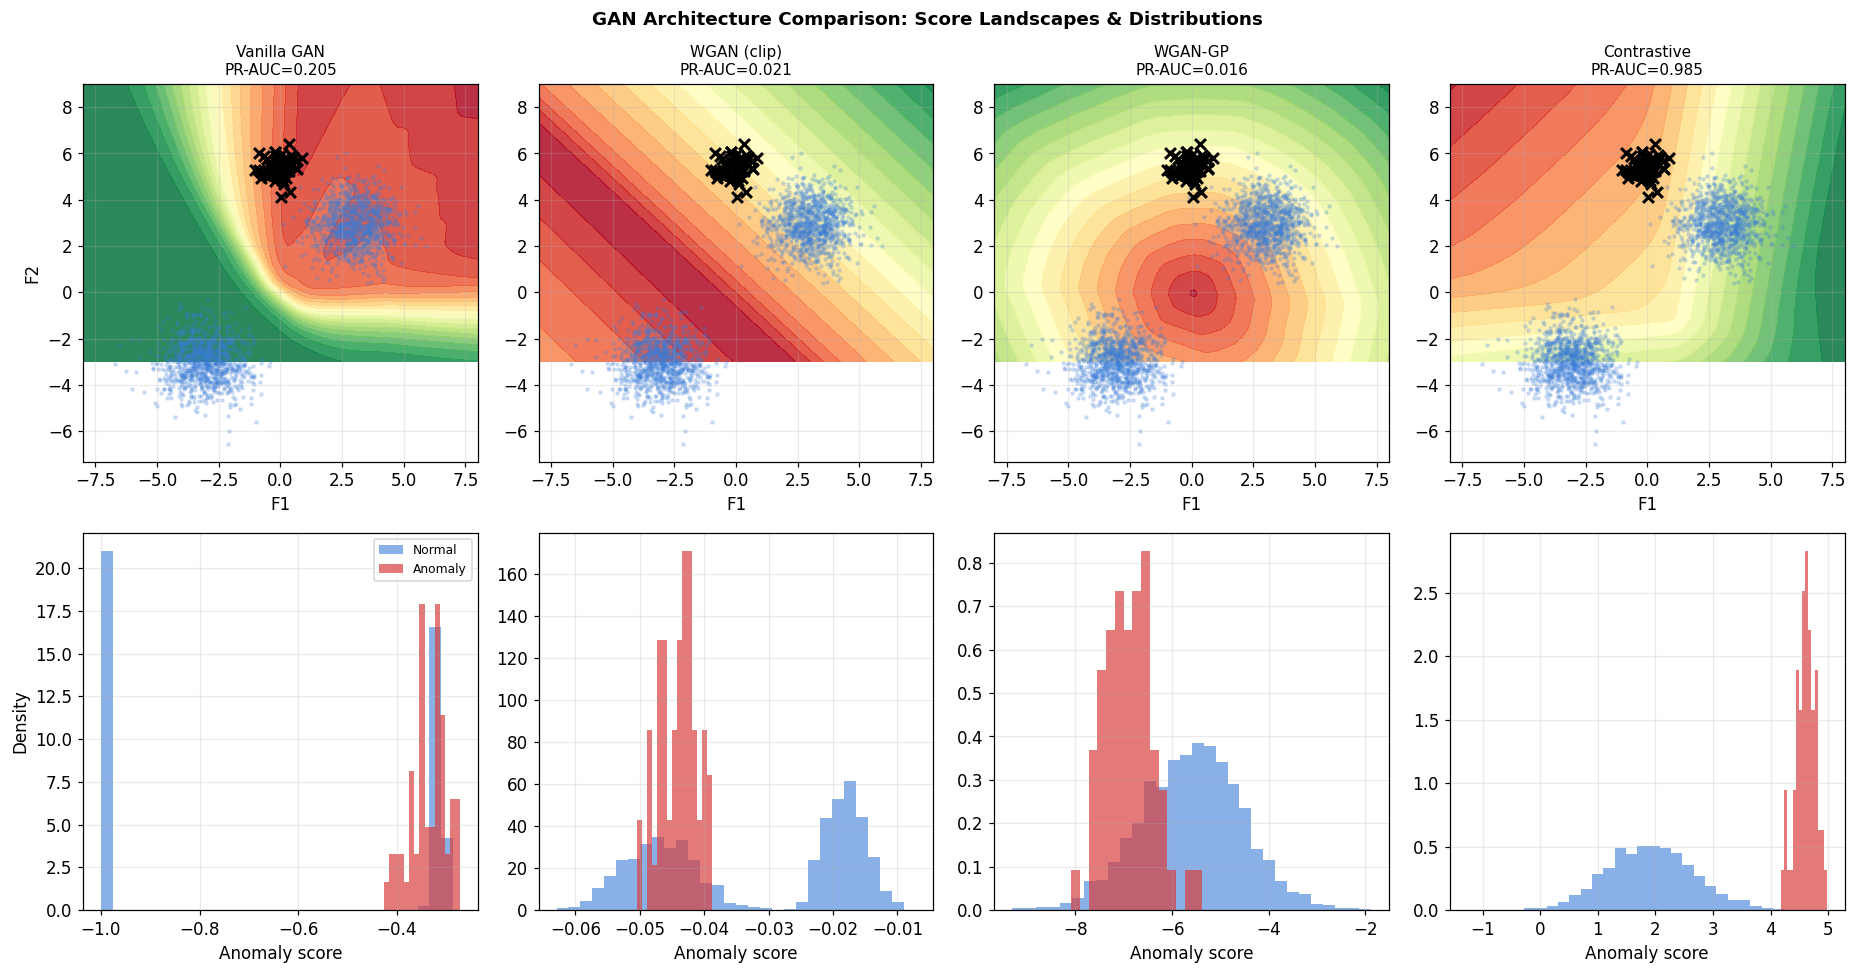


════════════════════════════════════════════════════════════
  FINAL COMPARISON SUMMARY
════════════════════════════════════════════════════════════
  Model                   PR-AUC    ROC-AUC
  ────────────────────────────────────────
  Vanilla GAN             0.2048     0.6784
  WGAN (clip)             0.0212     0.3379
  WGAN-GP                 0.0163     0.1316
  Contrastive             0.9849     0.9997
  Random baseline         0.0291     0.5000
════════════════════════════════════════════════════════════


In [35]:
# ── Final comparison: Vanilla vs WGAN vs WGAN-GP vs Contrastive

models_to_compare = {
    'Vanilla GAN':    (D_van,  'vanilla'),
    'WGAN (clip)':    (C_wgan_clip, 'wgan'),
    'WGAN-GP':        (C_gp,   'wgp'),
    'Contrastive':    (C_dash, 'cont'),
}

fig, axes = plt.subplots(2, 4, figsize=(17, 9))

xg = np.linspace(-8, 8, 80)
yg = np.linspace(-3, 9, 80)
XX, YY = np.meshgrid(xg, yg)
grid_t  = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)

results = {}

for col, (name, (model, mtype)) in enumerate(models_to_compare.items()):
    model.eval()
    with torch.no_grad():
        if mtype == 'vanilla':
            Z_raw = D_van(grid_t).numpy().reshape(80, 80)
            sc_n  = D_van(torch.tensor(NORMAL_DATA,  dtype=torch.float32)).squeeze().numpy()
            sc_a  = D_van(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()
            # anomaly = low D(x) → -D(x)
            Z_an  = -Z_raw; sc_n = -sc_n; sc_a = -sc_a
        else:
            Z_raw = model(grid_t).squeeze().numpy().reshape(80, 80)
            sc_n  = model(torch.tensor(NORMAL_DATA,  dtype=torch.float32)).squeeze().numpy()
            sc_a  = model(torch.tensor(ANOMALY_DATA, dtype=torch.float32)).squeeze().numpy()
            Z_an  = -Z_raw; sc_n = -sc_n; sc_a = -sc_a

    all_sc  = np.concatenate([sc_n, sc_a])
    all_lbl = np.concatenate([np.zeros(N_NORMAL), np.ones(N_ANOMALY)])
    pr_auc_val  = average_precision_score(all_lbl, all_sc)
    roc_auc_val = roc_auc_score(all_lbl, all_sc)
    results[name] = {'pr': pr_auc_val, 'roc': roc_auc_val}

    # Row 0: score landscapes
    ax = axes[0, col]
    cf = ax.contourf(XX, YY, Z_an, levels=20, cmap='RdYlGn_r', alpha=0.85)
    ax.scatter(NORMAL_DATA[:,0],  NORMAL_DATA[:,1],  s=4,  c=CBLUE, alpha=0.2)
    ax.scatter(ANOMALY_DATA[:,0], ANOMALY_DATA[:,1], s=50, c='black', marker='x',
               linewidths=2, zorder=3)
    ax.set_title(f'{name}\nPR-AUC={pr_auc_val:.3f}', fontsize=10)
    ax.set_xlabel('F1'); ax.set_ylabel('F2' if col == 0 else '')

    # Row 1: score distributions
    ax = axes[1, col]
    ax.hist(sc_n, bins=30, color=CBLUE, alpha=0.6, density=True, label='Normal')
    ax.hist(sc_a, bins=15, color=CRED,  alpha=0.7, density=True, label='Anomaly')
    ax.set_xlabel('Anomaly score'); ax.set_ylabel('Density' if col == 0 else '')
    if col == 0:
        ax.legend(fontsize=8)

    model.train()

plt.suptitle('GAN Architecture Comparison: Score Landscapes & Distributions',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Summary table
print("\n" + "═"*60)
print("  FINAL COMPARISON SUMMARY")
print("═"*60)
print(f"  {'Model':<20}  {'PR-AUC':>8}  {'ROC-AUC':>9}")
print("  " + "─"*40)
random_pr = N_ANOMALY / (N_NORMAL + N_ANOMALY)
for name, v in results.items():
    print(f"  {name:<20}  {v['pr']:>8.4f}  {v['roc']:>9.4f}")
print(f"  {'Random baseline':<20}  {random_pr:>8.4f}  {'0.5000':>9}")
print("═"*60)

---
## Summary & Connection to Production Code

### What We Built Step-by-Step

```
Vanilla GAN          Wasserstein GAN        WGAN-GP            Contrastive + MoE
──────────           ───────────────        ───────            ─────────────────
BCE loss             Wasserstein loss        + Grad Penalty     + Projection head
ReLU                 LeakyReLU               + Spectral Norm    + MoE experts
Sigmoid output       Unbounded output        + Layer Norm       + Feature mean
Unstable             More stable             Stable             Most expressive
Low PR-AUC           Better PR-AUC           Good PR-AUC        Best PR-AUC
```

### Key Equations (Full System)

**Critic loss:**
$$\mathcal{L}_C = \mathbb{E}[C(\tilde{x})] - \mathbb{E}[C(x)] + \lambda_{GP} \mathbb{E}\!\left[(\|\nabla C(\hat{x})\|_2 - 1)^2\right]$$

**Generator loss:**
$$\mathcal{L}_G = -\mathbb{E}_z[C(G(x, z))] + \lambda_r \cdot \mathbb{E}\!\left[\|G(x,z) - x\|^2\right]$$

**Anomaly score:**
$$\text{Score}(x) = -C(x) + \lambda_f \cdot \|p(x) - \bar{p}\|_2$$

**Threshold selection:**
$$\tau^* = \arg\max_\tau F_1(\tau) = \arg\max_\tau \frac{2 \cdot P(\tau) \cdot R(\tau)}{P(\tau) + R(\tau)}$$

### Production Checklist

- [ ] Fit scaler on **training normals only** (no leakage)
- [ ] 3-way split: **train / val / test** (test never touched during tuning)
- [ ] Monitor **Wasserstein distance**, **GP value**, **grad norms**, **PR-AUC**
- [ ] Check **covariance determinant** for mode collapse every epoch
- [ ] Save **best model by val PR-AUC**, not last model
- [ ] Apply **early stopping with patience** (e.g. patience=15)
- [ ] Run **Optuna** for hyperparameter search over architecture + training params
- [ ] Evaluate **only once** on test set after all tuning is complete
- [ ] Report **PR-AUC + ROC-AUC + F1** at optimal threshold
- [ ] Check **score direction**: fraud anomaly score > normal anomaly score

### Further Reading

- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661)
- Arjovsky et al. (2017) — [Wasserstein GAN](https://arxiv.org/abs/1701.07875)
- Gulrajani et al. (2017) — [Improved Training of WGANs](https://arxiv.org/abs/1704.00028)
- Miyato et al. (2018) — [Spectral Normalisation for GANs](https://arxiv.org/abs/1802.05957)
- Mescheder et al. (2018) — [Which Training Methods for GANs Do Actually Converge?](https://arxiv.org/abs/1801.04406)